## Student No.: 21423296    

## Data Source: BlueMotive Cars

In [5125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
from matplotlib.colors import LogNorm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
import re

## Data Preprocessing

The CVS file is read in using pandas, and the first ten rows of data entries are displayed

In [5126]:
# Load in the data set and print first 10 data entries
df=pd.read_csv('Car_Sales_data.csv')
df.head(10)

C:\Users\jackt\Documents\4th Year\DataScience\.venv\Lib\site-packages\IPython\core\displayhook.py:281: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


,Make-Model,Date of Sale,Sale Price,Year,Mileage,Classification,Transmission,Fuel Type,Description,Sale Location
0,Audi A1 (TFSI),06/01/2024,"€4,800.00",2012,"130,377",Hatchback,Manual,Petrol,Grey Audi A1 1.4 TFSI Sport Euro 5 (s/s) 3dr 2...,Waterford
1,Audi Q7 (S line Plus),07/01/2024,"€14,450.00",2012,"91,483",SUV,Automatic,Diesel,Blue Audi Q7 3.0 TDI S line Plus Tiptronic qua...,Clare
2,Audi RS3 (TFSI),09/01/2024,"€70,256.00",2022,"3,869",Saloon,Automatic,Petrol,Black Audi RS3 SALOON 2.5 RS 3 TFSI QUATTRO VO...,Mayo
3,Audi A3 (S line),09/01/2024,"€10,308.00",2013,"83,389",Hatchback,Manual,Diesel,Black Audi A3 2.0 TDI S line Hatchback 3dr Die...,Limerick
4,Audi A6 Saloon (ultra),2024-01-09,"€21,833.00",2018,"42,918",Saloon,Automatic,Diesel,Red Audi A6 Saloon 2.0 TDI Ultra Black Edition...,Dublin
5,Audi S3 (TFSI),2024-01-09,"€20,345.00",2016,73451,Hatchback,Automatic,Petrol,Blue Audi S3 2.0 TFSI Sportback 5dr Petrol S T...,Laois
6,Audi Q2 (TFSI),10/01/2024,"€27,307.00",2020,"17,520",SUV,Automatic,Petrol,Audi Q2 S line 35 TFSI 150 PS S tronic 1.5 5dr,Dublin
7,Audi Q2 (CoD),10/01/2024,"€19,056.00",2018,"60,224",SUV,Automatic,Petrol,Blue Audi Q2 1.4 TFSI CoD S line S Tronic Euro...,Donegal
8,Audi TT (TFSI),10/01/2024,"€ 7,166",2009,"55,056",Convertible,Manual,Petrol,Red Audi TT 2.0 TFSI Roadster 2dr Petrol Manua...,Dublin
9,Audi Q2 (TFSI),10/01/2024,"€21,153.00",2018,"32,692",SUV,Manual,Petrol,Navy Audi Q2 S line 1.4 TFSI cylinder on deman...,Cork


In [5127]:
# Select categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

# print unique values with counts
for col in categorical_columns:
    print(f"Column: {col}")
    print(df[col].value_counts())



Column: Make-Model
Make-Model
Mercedes-Benz C Class (Sport)        16
BMW 1 Series (M Sport)               15
Mercedes-Benz C Class (C220d)        15
Volkswagen Tiguan (TDI)              14
Mercedes-Benz E Class (E220d)        14
                                     ..
Volkswagen ID.4 (Pro Performance)     1
Volkswagen Golf (MHEV)                1
Volkswagen Scirocco (GT)              1
BMW M2 (i)                            1
BMW X3 (xLine)                        1
Name: count, Length: 560, dtype: int64
Column: Date of Sale
Date of Sale
19/10/2024    11
11/12/2024    10
12/08/2024    10
03/11/2024     9
23/11/2024     8
              ..
2024-10-08     1
04/11/2024     1
2024-11-21     1
2024-12-01     1
21/12/2024     1
Name: count, Length: 553, dtype: int64
Column: Sale Price
Sale Price
€14,293.00    2
€11,291.00    2
€15,450.00    2
€30,455.00    2
€9,960.00     2
             ..
€29,958.00    1
€16,821.00    1
€4,183.00     1
€ 10,690      1
€17,864.00    1
Name: count, Length: 1663

## Step 1: Data Cleaning and Date Parsing

## 1.1 Date of Sale Cleaning

### Cleaning Type
Date format normalization and datetime conversion.

### Exact Cleaning Done
- Trim whitespace from each value and cast to string.
- Parse values containing `-` with `yearfirst=True` (ISO-like format).
- Parse other values with `dayfirst=True` (European-style format).
- Convert the full column to pandas `datetime`.

In [5128]:
def parse_date(date):
    # Convert input to string
    date = str(date).strip()
    
    if '-' in date:
        return pd.to_datetime(date, yearfirst=True)  # Convert using ISO format
    else:
        return pd.to_datetime(date, dayfirst=True)  # Convert using European format

# Apply the function to the Date of Sale
df['Date of Sale'] = df['Date of Sale'].apply(parse_date)

## 1.2 Sale Price Cleaning

### Cleaning Type
Currency symbol removal and numeric conversion.

### Exact Cleaning Done
- Remove euro symbols and commas using regex replacement.
- Convert cleaned values to `float` for numeric analysis.

In [5129]:
# Remove the euro and commas from the column adn convert to type float
df['Sale Price'] =df['Sale Price'].replace({'€': '', ',': ''}, regex=True).astype(float)

## 1.3 Mileage Cleaning

### Cleaning Type
Non-digit character stripping and integer conversion.

### Exact Cleaning Done
- Convert values to string first.
- Remove every non-digit character with regex (`[^\d]`).
- Convert cleaned values to `int`.

In [5130]:
# Remove non digit characters and covert to int
df['Mileage'] = df['Mileage'].astype(str).replace({r'[^\d]': ''}, regex=True).astype(int)

## 1.4 Year Cleaning

### Cleaning Type
Data type normalization for year values.

### Exact Cleaning Done
- Convert `Year` to numeric using `pd.to_numeric(..., errors='coerce')`.
- Coerce invalid year values to `NaN`.

In [5131]:
# Convert year to numeric values
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

## 1.5 Text Column Cleaning

### Cleaning Type
Whitespace trimming and label standardization.

### Exact Cleaning Done
- Strip leading and trailing whitespace in selected text columns.
- Standardize repeated labels in `Classification`: `S.U.V.` -> `SUV`.
- Standardize repeated labels in `Transmission`: `Auto` -> `Automatic`.

In [5132]:
text_columns = ['Make-Model', 'Classification', 'Transmission', 'Fuel Type', 'Description', 'Sale Location']
# In the text columns remove any whitespace
for col in text_columns:
    df[col] = df[col].astype(str).str.strip()
    
# Change repeat unique values
df['Classification'] = df['Classification'].replace({'S.U.V.': 'SUV'})
df['Transmission'] = df['Transmission'].replace({'Auto': 'Automatic'})

## 1.6 First 10 Entries of Cleaned Data Shown

In [5133]:
# Display first 10 entries of the cleaned data
df.head(10)

,Make-Model,Date of Sale,Sale Price,Year,Mileage,Classification,Transmission,Fuel Type,Description,Sale Location
0,Audi A1 (TFSI),2024-01-06,4800.0,2012,130377,Hatchback,Manual,Petrol,Grey Audi A1 1.4 TFSI Sport Euro 5 (s/s) 3dr 2...,Waterford
1,Audi Q7 (S line Plus),2024-01-07,14450.0,2012,91483,SUV,Automatic,Diesel,Blue Audi Q7 3.0 TDI S line Plus Tiptronic qua...,Clare
2,Audi RS3 (TFSI),2024-01-09,70256.0,2022,3869,Saloon,Automatic,Petrol,Black Audi RS3 SALOON 2.5 RS 3 TFSI QUATTRO VO...,Mayo
3,Audi A3 (S line),2024-01-09,10308.0,2013,83389,Hatchback,Manual,Diesel,Black Audi A3 2.0 TDI S line Hatchback 3dr Die...,Limerick
4,Audi A6 Saloon (ultra),2024-01-09,21833.0,2018,42918,Saloon,Automatic,Diesel,Red Audi A6 Saloon 2.0 TDI Ultra Black Edition...,Dublin
5,Audi S3 (TFSI),2024-01-09,20345.0,2016,73451,Hatchback,Automatic,Petrol,Blue Audi S3 2.0 TFSI Sportback 5dr Petrol S T...,Laois
6,Audi Q2 (TFSI),2024-01-10,27307.0,2020,17520,SUV,Automatic,Petrol,Audi Q2 S line 35 TFSI 150 PS S tronic 1.5 5dr,Dublin
7,Audi Q2 (CoD),2024-01-10,19056.0,2018,60224,SUV,Automatic,Petrol,Blue Audi Q2 1.4 TFSI CoD S line S Tronic Euro...,Donegal
8,Audi TT (TFSI),2024-01-10,7166.0,2009,55056,Convertible,Manual,Petrol,Red Audi TT 2.0 TFSI Roadster 2dr Petrol Manua...,Dublin
9,Audi Q2 (TFSI),2024-01-10,21153.0,2018,32692,SUV,Manual,Petrol,Navy Audi Q2 S line 1.4 TFSI cylinder on deman...,Cork


## Step 2: Feature Engineering

## 2.1 Splitting "Make-Model" into "Make" and "Model"

The "Make-Model" column contained both the manufacturer and model information. It is split into two separate columns, this allows for independent analysis by make and by model. Specifications or extra information enclosed in brackets within the "Model" are removed to retain only the core model name.

In [5134]:
df['Make']=df['Make-Model'].apply(lambda x: x.split()[0])
df['Model']=df['Make-Model'].apply(lambda x: ' '.join(x.split()[1:]))
df['Model']= df['Model'].str.replace(r'\([^)]*\)', '', regex=True).str.strip()

## 2.2 Calculating Car Age

Car age at the time of sale was calculated by subtracting the manufacturing year from the sale year. This feature is important for understanding depreciation in later analysis.

In [5135]:
df['Car Age'] = 2024 - df['Year']
df.loc[df['Car Age']< 0, 'Car Age'] = 0 

## 2.3 Extracting Additional Features from "Description"

Additional details were extracted from the "Description". This was done to provide extra information for analysis

Car Colour: A list of common colours was searched for in the description.
Engine Size: The first occurrence of a decimal number ("3.0" or "2.1") was extracted.
Previous Owners: A number preceding the term "previous owner" was extracted and increased by with a default of 1 if not found as it is second hand car sales.

In [5136]:
# Function to extract car colour from the description.
def extract_color(description):
    colors = ['Black', 'Blue', 'Red', 'Grey', 'Silver', 'White', 'Green', 'Yellow', 'Orange', 'Brown', 'Maroon', 'Gold', 'Navy']
    description_lower = description.lower()
    for color in colors:
        if color.lower() in description_lower:
            return color  # Return the first matching colour
    return None

# Function to extract engine size as a decimal number (e.g., 3.0, 2.1) from the description.
def extract_engine_size(description):
    # find a number with a decimal point.
    match = re.search(r'\b\d+\.\d', description)
    if match:
        return match.group(0)
    return None

def extract_previous_owners(description):
    match = re.search(r'(\d+)\s*previous owner[s]?', description, re.IGNORECASE)
    if match:
        return int(match.group(1))+1
    return 1

df['Previous Owners'] = df['Description'].apply(extract_previous_owners)
df['Car Colour'] = df['Description'].apply(extract_color)
df['Engine Size'] = df['Description'].apply(extract_engine_size)


## 2.4 Filling Missing Values in Extracted Features

Missing values in the extracted "Car Colour" and "Engine Size" columns filled with the most common (mode) value.

In [5137]:
common_color = df['Car Colour'].mode()[0]
# most common engine size.
non_electric = df[df['Fuel Type'] != 'Electric']
common_engine_size = non_electric['Engine Size'].mode()[0]

# For electric vehicles Engine Size to NaN
df.loc[df['Fuel Type'] == 'Electric', 'Engine Size'] = np.nan

# replace empty values with the mode
no_engine_size = (df['Fuel Type'] != 'Electric') & (df['Engine Size'].isnull())
no_colour = df['Car Colour'].isnull()
df.loc[no_engine_size, 'Engine Size'] = common_engine_size
df.loc[no_colour, 'Car Colour'] = common_color
df

,Make-Model,Date of Sale,Sale Price,Year,Mileage,Classification,Transmission,Fuel Type,Description,Sale Location,Make,Model,Car Age,Previous Owners,Car Colour,Engine Size
0,Audi A1 (TFSI),2024-01-06,4800.0,2012,130377,Hatchback,Manual,Petrol,Grey Audi A1 1.4 TFSI Sport Euro 5 (s/s) 3dr 2...,Waterford,Audi,A1,12,3,Grey,1.4
1,Audi Q7 (S line Plus),2024-01-07,14450.0,2012,91483,SUV,Automatic,Diesel,Blue Audi Q7 3.0 TDI S line Plus Tiptronic qua...,Clare,Audi,Q7,12,2,Blue,3.0
2,Audi RS3 (TFSI),2024-01-09,70256.0,2022,3869,Saloon,Automatic,Petrol,Black Audi RS3 SALOON 2.5 RS 3 TFSI QUATTRO VO...,Mayo,Audi,RS3,2,3,Black,2.5
3,Audi A3 (S line),2024-01-09,10308.0,2013,83389,Hatchback,Manual,Diesel,Black Audi A3 2.0 TDI S line Hatchback 3dr Die...,Limerick,Audi,A3,11,5,Black,2.0
4,Audi A6 Saloon (ultra),2024-01-09,21833.0,2018,42918,Saloon,Automatic,Diesel,Red Audi A6 Saloon 2.0 TDI Ultra Black Edition...,Dublin,Audi,A6 Saloon,6,1,Black,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1695,Volkswagen Tiguan (R-Line),2024-12-19,14075.0,2015,73104,SUV,Automatic,Diesel,Volkswagen Tiguan 2.0 R LINE TDI BLUEMOTION TE...,Tipperary,Volkswagen,Tiguan,9,3,Blue,2.0
1696,Volkswagen Tiguan (R-Line),2024-12-20,27755.0,2017,26055,SUV,Automatic,Petrol,Volkswagen Tiguan 2.0 TSI R-Line DSG 4Motion (...,Wexford,Volkswagen,Tiguan,7,1,Blue,2.0
1697,Volkswagen Passat (BlueMotion Tech),2024-12-21,13503.0,2015,53236,Saloon,Manual,Diesel,Volkswagen Passat 2.0 TDI SE Business 4dr 2 pr...,Tipperary,Volkswagen,Passat,9,3,Blue,2.0
1698,Volkswagen Golf (MHEV),2024-12-22,29262.0,2021,3143,Hatchback,Automatic,Petrol Hybrid,Volkswagen Golf 1.5 R-LINE ETSI DSG 5d 148 BHP...,Galway,Volkswagen,Golf,3,1,Blue,1.5


## 2.5 Binning Continuous Variables

Continuous variables were binned into categories to simplify analysis:

Mileage Category: Mileage was divided into bins ('Low', 'Moderate', 'High', 'Very High').
Age Category: Car age was categorized into bins ('New', 'Lightly Used', 'Moderately Used', 'Heavily Used', 'Old').
Price Category: Price was categorized into bins ('Budget', 'Affordable', 'Mid-range', 'Expensive', 'Very Expensive').

In [5138]:
mileage_bins = [0, 20000, 50000, 100000, df['Mileage'].max()]
mileage_labels = ['Low','Moderate','High','Very High']
df['Mileage Category'] = pd.cut(df['Mileage'], bins=mileage_bins,labels=mileage_labels)

age_bins = [0, 1, 3, 5, 10, df['Car Age'].max()]
age_labels = ['New','Lightly Used','Moderately Used','Heavily Used','Old']
df['Age Category'] =pd.cut(df['Car Age'], bins=age_bins, labels=age_labels)

Price_bins = [0, 15000, 20000, 30000, 50000, df['Sale Price'].max()]
Price_labels = ['Budget', 'Affordable', 'Mid-range', 'Expensive', 'Very Expensive']
df['Price Category'] = pd.cut(df['Sale Price'], bins=Price_bins, labels=Price_labels, include_lowest=True)


## 2.6 Normalization of Numeric Features

Min-max normalization is applied to numeric features (Sale Price, Mileage, and Car Age) to rescale their values to a common range [0, 1] using the follwoing formula:
$$
X' = \frac{X - X_{\min}}{X_{\max} - X_{\min}}
$$

In [5139]:
# Normalization function
def min_max_normalize(series):
    return (series - series.min()) / (series.max() - series.min())

df['Sale Price Norm'] = min_max_normalize(df['Sale Price'])
df['Mileage Norm'] = min_max_normalize(df['Mileage'])
df['Car Age Norm'] = min_max_normalize(df['Car Age'])

df

,Make-Model,Date of Sale,Sale Price,Year,Mileage,Classification,Transmission,Fuel Type,Description,Sale Location,...,Car Age,Previous Owners,Car Colour,Engine Size,Mileage Category,Age Category,Price Category,Sale Price Norm,Mileage Norm,Car Age Norm
0,Audi A1 (TFSI),2024-01-06,4800.0,2012,130377,Hatchback,Manual,Petrol,Grey Audi A1 1.4 TFSI Sport Euro 5 (s/s) 3dr 2...,Waterford,...,12,3,Grey,1.4,Very High,Old,Budget,0.017031,0.667902,0.714286
1,Audi Q7 (S line Plus),2024-01-07,14450.0,2012,91483,SUV,Automatic,Diesel,Blue Audi Q7 3.0 TDI S line Plus Tiptronic qua...,Clare,...,12,2,Blue,3.0,High,Old,Budget,0.062072,0.468614,0.714286
2,Audi RS3 (TFSI),2024-01-09,70256.0,2022,3869,Saloon,Automatic,Petrol,Black Audi RS3 SALOON 2.5 RS 3 TFSI QUATTRO VO...,Mayo,...,2,3,Black,2.5,Low,Lightly Used,Very Expensive,0.322541,0.019691,0.000000
3,Audi A3 (S line),2024-01-09,10308.0,2013,83389,Hatchback,Manual,Diesel,Black Audi A3 2.0 TDI S line Hatchback 3dr Die...,Limerick,...,11,5,Black,2.0,High,Old,Budget,0.042739,0.427141,0.642857
4,Audi A6 Saloon (ultra),2024-01-09,21833.0,2018,42918,Saloon,Automatic,Diesel,Red Audi A6 Saloon 2.0 TDI Ultra Black Edition...,Dublin,...,6,1,Black,2.0,Moderate,Heavily Used,Mid-range,0.096531,0.219773,0.285714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1695,Volkswagen Tiguan (R-Line),2024-12-19,14075.0,2015,73104,SUV,Automatic,Diesel,Volkswagen Tiguan 2.0 R LINE TDI BLUEMOTION TE...,Tipperary,...,9,3,Blue,2.0,High,Heavily Used,Budget,0.060321,0.374442,0.500000
1696,Volkswagen Tiguan (R-Line),2024-12-20,27755.0,2017,26055,SUV,Automatic,Petrol,Volkswagen Tiguan 2.0 TSI R-Line DSG 4Motion (...,Wexford,...,7,1,Blue,2.0,Moderate,Heavily Used,Mid-range,0.124172,0.133369,0.357143
1697,Volkswagen Passat (BlueMotion Tech),2024-12-21,13503.0,2015,53236,Saloon,Manual,Diesel,Volkswagen Passat 2.0 TDI SE Business 4dr 2 pr...,Tipperary,...,9,3,Blue,2.0,High,Heavily Used,Budget,0.057652,0.272641,0.500000
1698,Volkswagen Golf (MHEV),2024-12-22,29262.0,2021,3143,Hatchback,Automatic,Petrol Hybrid,Volkswagen Golf 1.5 R-LINE ETSI DSG 5d 148 BHP...,Galway,...,3,1,Blue,1.5,Low,Lightly Used,Mid-range,0.131205,0.015971,0.071429


## 2.7 Dummy Encoding for Categorical Variables

Categorical variables transformed into binary indicator variables using dummy encoding in a new data frame. This conversion allows categorical data to be used in regression and other predictive models.

In [5140]:
df_copy = df.copy()
categorical_cols = ['Classification', 'Transmission', 'Fuel Type', 'Sale Location', 'Car Colour', 'Make', 'Mileage Category', 'Age Category', 'Model']
dfcopy = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

## Data Analysis

## Step 3: Exploratory Data Analysis

In [5141]:
# Display the basic summary statistics for numeric features
print(df.describe())

                        Date of Sale     Sale Price         Year  \
count                           1700    1700.000000  1700.000000   
mean   2024-07-02 19:58:35.294117632   21732.065882  2016.150000   
min              2024-01-02 00:00:00    1151.000000  2008.000000   
25%              2024-04-04 00:00:00   11042.500000  2014.000000   
50%              2024-07-06 12:00:00   17704.000000  2017.000000   
75%              2024-09-30 00:00:00   27176.500000  2019.000000   
max              2024-12-22 00:00:00  215403.000000  2022.000000   
std                              NaN   16455.951135     3.458043   

             Mileage      Car Age  Previous Owners  Sale Price Norm  \
count    1700.000000  1700.000000      1700.000000      1700.000000   
mean    53320.732941     7.850000         2.304118         0.096060   
min        26.000000     2.000000         1.000000         0.000000   
25%     23394.000000     5.000000         1.000000         0.046168   
50%     47644.500000     7.00000

In [5142]:
# Display information about the DataFrame: data types and non-null counts.
print(df.info())
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Make-Model        1700 non-null   object        
 1   Date of Sale      1700 non-null   datetime64[ns]
 2   Sale Price        1700 non-null   float64       
 3   Year              1700 non-null   int64         
 4   Mileage           1700 non-null   int64         
 5   Classification    1700 non-null   object        
 6   Transmission      1700 non-null   object        
 7   Fuel Type         1700 non-null   object        
 8   Description       1700 non-null   object        
 9   Sale Location     1700 non-null   object        
 10  Make              1700 non-null   object        
 11  Model             1700 non-null   object        
 12  Car Age           1700 non-null   int64         
 13  Previous Owners   1700 non-null   int64         
 14  Car Colour        1700 n

,Make-Model,Date of Sale,Sale Price,Year,Mileage,Classification,Transmission,Fuel Type,Description,Sale Location,...,Car Age,Previous Owners,Car Colour,Engine Size,Mileage Category,Age Category,Price Category,Sale Price Norm,Mileage Norm,Car Age Norm
0,Audi A1 (TFSI),2024-01-06,4800.0,2012,130377,Hatchback,Manual,Petrol,Grey Audi A1 1.4 TFSI Sport Euro 5 (s/s) 3dr 2...,Waterford,...,12,3,Grey,1.4,Very High,Old,Budget,0.017031,0.667902,0.714286
1,Audi Q7 (S line Plus),2024-01-07,14450.0,2012,91483,SUV,Automatic,Diesel,Blue Audi Q7 3.0 TDI S line Plus Tiptronic qua...,Clare,...,12,2,Blue,3.0,High,Old,Budget,0.062072,0.468614,0.714286
2,Audi RS3 (TFSI),2024-01-09,70256.0,2022,3869,Saloon,Automatic,Petrol,Black Audi RS3 SALOON 2.5 RS 3 TFSI QUATTRO VO...,Mayo,...,2,3,Black,2.5,Low,Lightly Used,Very Expensive,0.322541,0.019691,0.000000
3,Audi A3 (S line),2024-01-09,10308.0,2013,83389,Hatchback,Manual,Diesel,Black Audi A3 2.0 TDI S line Hatchback 3dr Die...,Limerick,...,11,5,Black,2.0,High,Old,Budget,0.042739,0.427141,0.642857
4,Audi A6 Saloon (ultra),2024-01-09,21833.0,2018,42918,Saloon,Automatic,Diesel,Red Audi A6 Saloon 2.0 TDI Ultra Black Edition...,Dublin,...,6,1,Black,2.0,Moderate,Heavily Used,Mid-range,0.096531,0.219773,0.285714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1695,Volkswagen Tiguan (R-Line),2024-12-19,14075.0,2015,73104,SUV,Automatic,Diesel,Volkswagen Tiguan 2.0 R LINE TDI BLUEMOTION TE...,Tipperary,...,9,3,Blue,2.0,High,Heavily Used,Budget,0.060321,0.374442,0.500000
1696,Volkswagen Tiguan (R-Line),2024-12-20,27755.0,2017,26055,SUV,Automatic,Petrol,Volkswagen Tiguan 2.0 TSI R-Line DSG 4Motion (...,Wexford,...,7,1,Blue,2.0,Moderate,Heavily Used,Mid-range,0.124172,0.133369,0.357143
1697,Volkswagen Passat (BlueMotion Tech),2024-12-21,13503.0,2015,53236,Saloon,Manual,Diesel,Volkswagen Passat 2.0 TDI SE Business 4dr 2 pr...,Tipperary,...,9,3,Blue,2.0,High,Heavily Used,Budget,0.057652,0.272641,0.500000
1698,Volkswagen Golf (MHEV),2024-12-22,29262.0,2021,3143,Hatchback,Automatic,Petrol Hybrid,Volkswagen Golf 1.5 R-LINE ETSI DSG 5d 148 BHP...,Galway,...,3,1,Blue,1.5,Low,Lightly Used,Mid-range,0.131205,0.015971,0.071429


## 3.1 Visualising Data Distributions & Market Segmentations

The Dataset's key distributions are visualised and analyzed to understand the market segmentation, pricing and geographical trends, along with purcahsing trends (engine size, car type, colour, fuel type):

Car Classification, Colour & Make: Reveals dominant vehicle types, vehicle colour and brands.

Engine Size: Highlights engine diversity and common trends.

Sale Location: Identifies geographic sale hotspots.

Vehicle Ownership: Distinguishes between new and used vehicles.

Fuel Type: Shows trends in energy sources.

Sale Price: Illustrates overall pricing and detects outliers.

Classification
Hatchback      499
SUV            448
Saloon         338
Coupe          159
Estate         146
Convertible    110
Name: count, dtype: int64


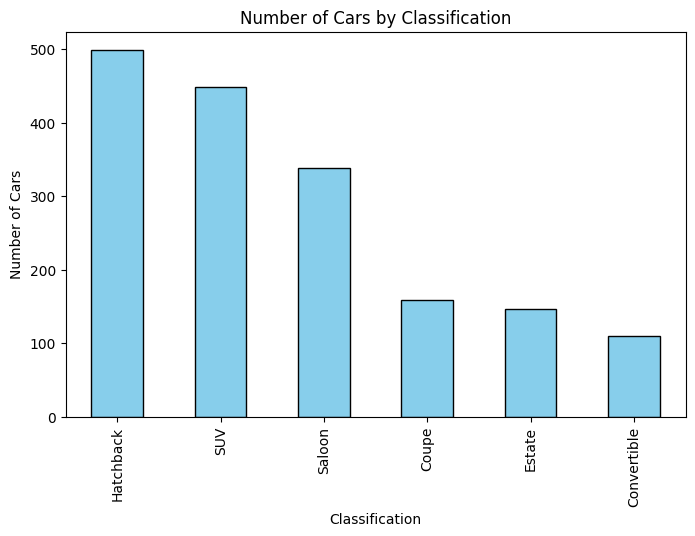

Make
Mercedes-Benz    593
BMW              396
Audi             384
Volkswagen       327
Name: count, dtype: int64


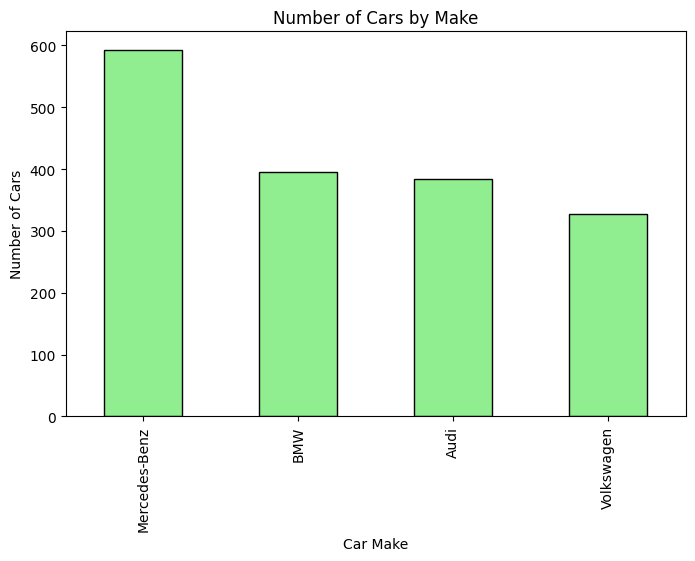

Car Colour
Blue      681
Black     377
Red       260
Grey      130
Navy      130
Silver    122
Name: count, dtype: int64


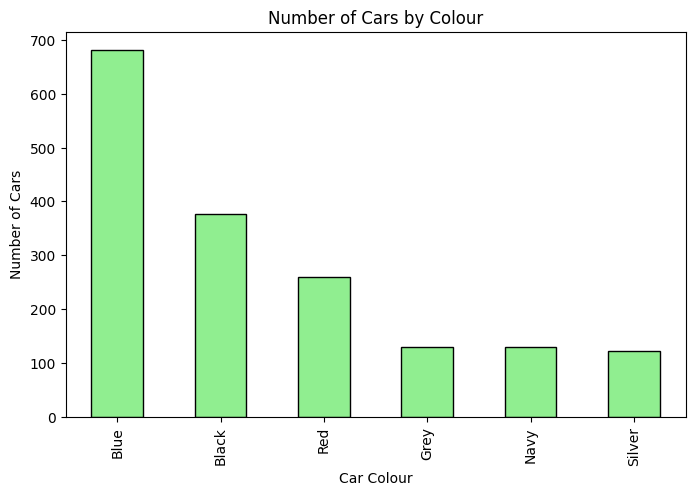

Engine Size
1.0     65
1.2     30
1.3     37
1.4     75
1.5    147
1.6    113
1.8     32
1.9      1
2.0    630
2.1    204
2.2      1
2.5      6
2.7      1
2.9     17
3.0    266
3.5      5
4.0     26
4.2      6
4.4      9
5.2      1
5.4      1
5.5      6
6.0      1
6.3      3
Name: count, dtype: int64


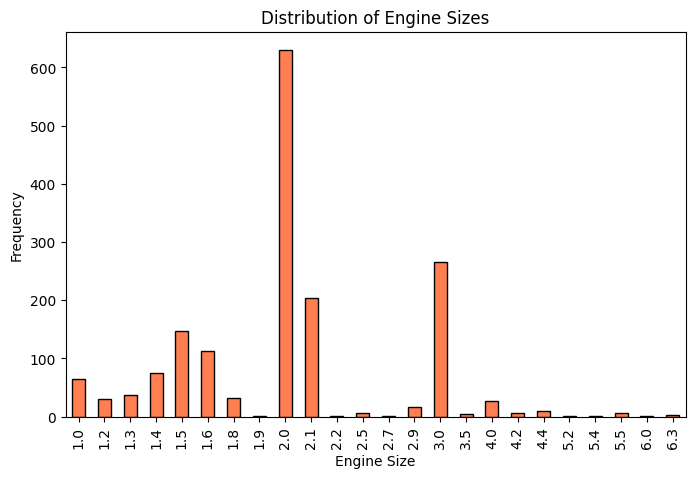

Previous Owners
2nd hand     675
3rd hand     359
4th hand     356
5th hand     173
6th hand      88
7th hand      35
8th hand      12
9th hand       1
23th hand      1
Name: count, dtype: int64


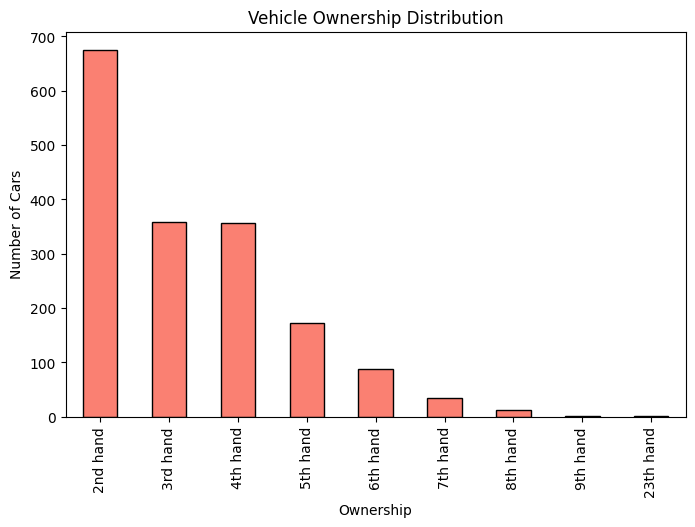

Fuel Type
Diesel                   922
Petrol                   691
Diesel Hybrid             30
Petrol Plug-In Hybrid     25
Electric                  17
Petrol Hybrid             13
Diesel Plug-In Hybrid      2
Name: count, dtype: int64


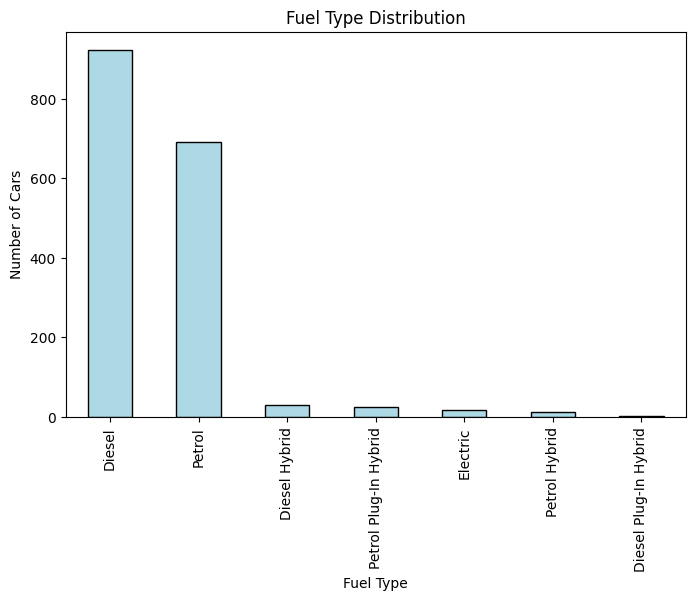

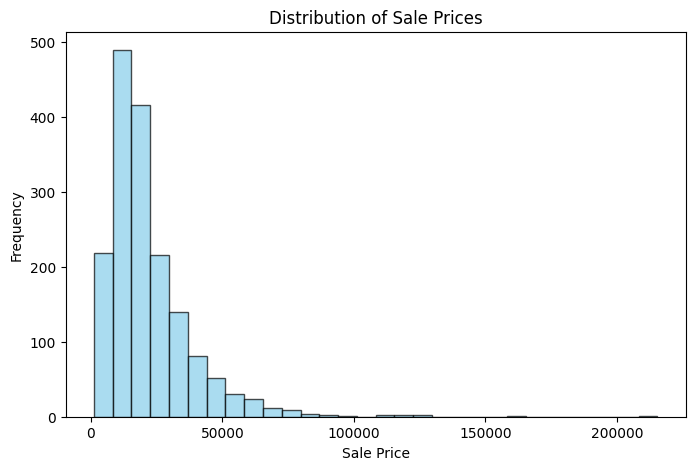

In [5143]:
# Tally by Car Classification
classification_tally = df['Classification'].value_counts()
print(classification_tally)

# Visualize as a bar chart
plt.figure(figsize=(8, 5))
classification_tally.plot(kind='bar', color='skyblue', edgecolor='k')
plt.xlabel('Classification')
plt.ylabel('Number of Cars')
plt.title('Number of Cars by Classification')
plt.show()

# Tally by Car Make
make_tally = df['Make'].value_counts()
print(make_tally)

# Visualize as a bar chart
plt.figure(figsize=(8, 5))
make_tally.plot(kind='bar', color='lightgreen', edgecolor='k')
plt.xlabel('Car Make')
plt.ylabel('Number of Cars')
plt.title('Number of Cars by Make')
plt.show()

# Frequency distribution of car colour
car_colour_freq = df['Car Colour'].value_counts()
print(car_colour_freq)

# Visualize as a bar chart
plt.figure(figsize=(8, 5))
car_colour_freq.plot(kind='bar', color='lightgreen', edgecolor='k')
plt.xlabel('Car Colour')
plt.ylabel('Number of Cars')
plt.title('Number of Cars by Colour')
plt.show()

# Frequency distribution of engine sizes
engine_size_freq = df['Engine Size'].value_counts().sort_index()
print(engine_size_freq)

# Visualize as a bar chart
plt.figure(figsize=(8, 5))
engine_size_freq.plot(kind='bar', color='coral', edgecolor='k')
plt.xlabel('Engine Size')
plt.ylabel('Frequency')
plt.title('Distribution of Engine Sizes')
plt.show()

# Convert Previous Owners count into labels:
prev_owner_counts = df['Previous Owners'].value_counts().sort_index()
def hand_label(x):
    if x == 0:
        return "1st hand"
    elif x == 1:
        return "2nd hand"
    elif x == 2:
        return "3rd hand"
    else:
        return f"{x+1}th hand"

# Map the index to hand labels
prev_owner_counts.index = prev_owner_counts.index.map(hand_label)
print(prev_owner_counts)

# Visualize as a bar chart
plt.figure(figsize=(8, 5))
prev_owner_counts.plot(kind='bar', color='salmon', edgecolor='k')
plt.xlabel('Ownership')
plt.ylabel('Number of Cars')
plt.title('Vehicle Ownership Distribution')
plt.show()

# Frequency distribution Fuel type
fuel_type_freq = df['Fuel Type'].value_counts()
print(fuel_type_freq)

# Visualize as a bar chart
plt.figure(figsize=(8, 5))
fuel_type_freq.plot(kind='bar', color='lightblue', edgecolor='k')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Cars')
plt.title('Fuel Type Distribution')
plt.show()

# Sale Price Distribution
plt.figure(figsize=(8, 5))
plt.hist(df['Sale Price'], bins=30, color='skyblue', edgecolor='k', alpha=0.7)
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.title('Distribution of Sale Prices')
plt.show()

**Interpretation of the results:**

**Classification:**
- Hatchbacks are the most common, followed by SUVs and then Saloons.
- Coupes, Estates, and Convertibles are less frequent, suggesting that everyday practical vehicles dominate the market.

**Make:**
- Mercedes-Benz leads with vehicles, followed by BMW, then Audi, and finally Volkswagen.
- This indicates a preference for premium brands, with Mercedes-Benz being the most popular.

**Car Colour:**
- The most popular colours are Blue and Black, with Red also popular but less so.
- This suggests that buyers lean towards classic, neutral shades.

**Engine Size:**
- The most common engine sizes are 2.0 (661), 2.1 (196), and 3.0 (263), with moderate representation of smaller engines (1.5 and 1.6).
- This diversity indicates a mix of performance and economy preferences, leaning towards mid-range engine sizes.

**Previous Owners (Vehicle Ownership):**
- A majority of vehicles are listed as 2nd hand with the next groups being 3rd hand and then 4th hand with about half the amount.
- This shows a strong secondary market because many vehicles change hands multiple times.

**Fuel Type:**
- Diesel and Petrol dominate the market, while hybrids and electric vehicles are much less common.
- This suggests that traditional fuel types remain the most prevalent, with a gradual introduction of alternative sources.

**Sale Price:**
- The histogram shows a right-skewed distribution. Most of the vehicles cluster at the lower prices (under 30,000 euro)
- There is a smaller number of a premiuim modeels sctreching into the higher ranges (up to 200,000 euro)
- This distribution displays that while budget friendly cars domiante the market that there is outliers representing high-end vehicles.

Overall, these results reveal that the market is dominated by practical vehicles, primarily hatchbacks and SUVs from premium brands, in classic colours, and mostly using diesel and petrol engines. These insights are vital for understanding market trends, inventory strategies, and for pricing decisions.


## 3.2 Heat Map of Sales Location Across Ireland

Created a heatmap of sale locations across the Irish counties using local GeoJSON data ("ie.json") and sales frequency data from the Sale Location column. 

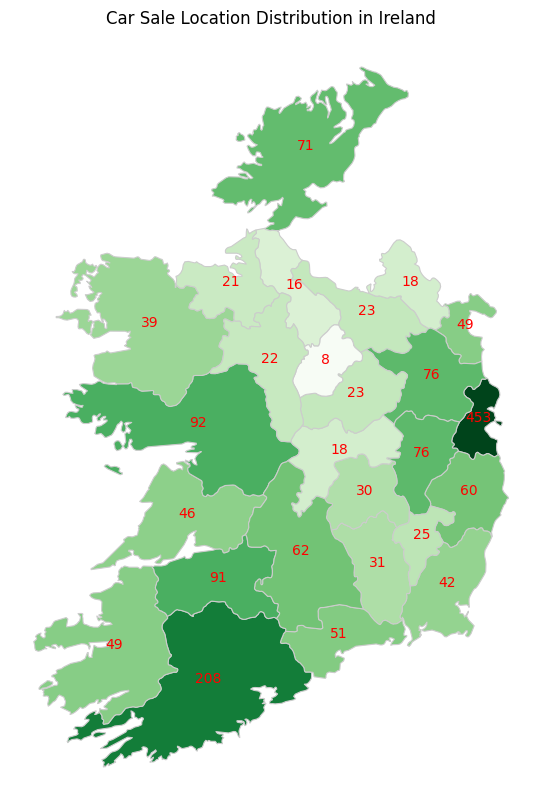

In [5144]:
sale_location_freq = df['Sale Location'].value_counts()

# Convert location counts to a df
sale_location_counts = sale_location_freq.rename_axis('name').to_frame('Sales')
sale_location_counts.index = sale_location_counts.index.astype(str).str.strip()

# Load the Irish counties GeoJSON
gdf = gpd.read_file("ie.json")
county_name_col=None
for col in gdf.columns:
    if 'name' in col.lower():
        county_name_col=col
        break

# replace "Laoighis" to "Laois"
gdf['name'] = gdf['name'].replace({"Laoighis": "Laois"})

# Merge the sales frequency data with GeoDataFrame
gdf = gdf.set_index("name").join(sale_location_counts,how="left").reset_index()
gdf['Sales'] = gdf['Sales'].fillna(0)

#Using logarithmic normalization.
gdf['Sales_for_norm'] =gdf['Sales'].replace(0,0.1)
normal = LogNorm(vmin=gdf['Sales_for_norm'].min(), vmax=gdf['Sales_for_norm'].max())

# Plot choropleth map.
fig, ax=plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column='Sales',cmap='Greens',norm=normal,linewidth=0.8, ax=ax, edgecolor='0.8')

# Add each county.
for idx, row in gdf.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, int(row['Sales']), horizontalalignment='center', color='red')

plt.title("Car Sale Location Distribution in Ireland")
ax.set_axis_off()
plt.show()

From the heatmap of car sales across the counties of Ireland it is clear that Dublin dominates sales, slight more than doubling the sales in Cork, while Galway and Limerick trail with around one quarter of the sales of Dublin. Counties like Longford show minimal activity, indicating that larger urban centers account for most of the sales volume, with smaller counties contributing far less.

## 3.3 Heat Map of Sales Location By Brand Across Ireland

Created a heatmap of sale locations across the Irish counties using local GeoJSON data ("ie.json") and sales frequency for each brand.

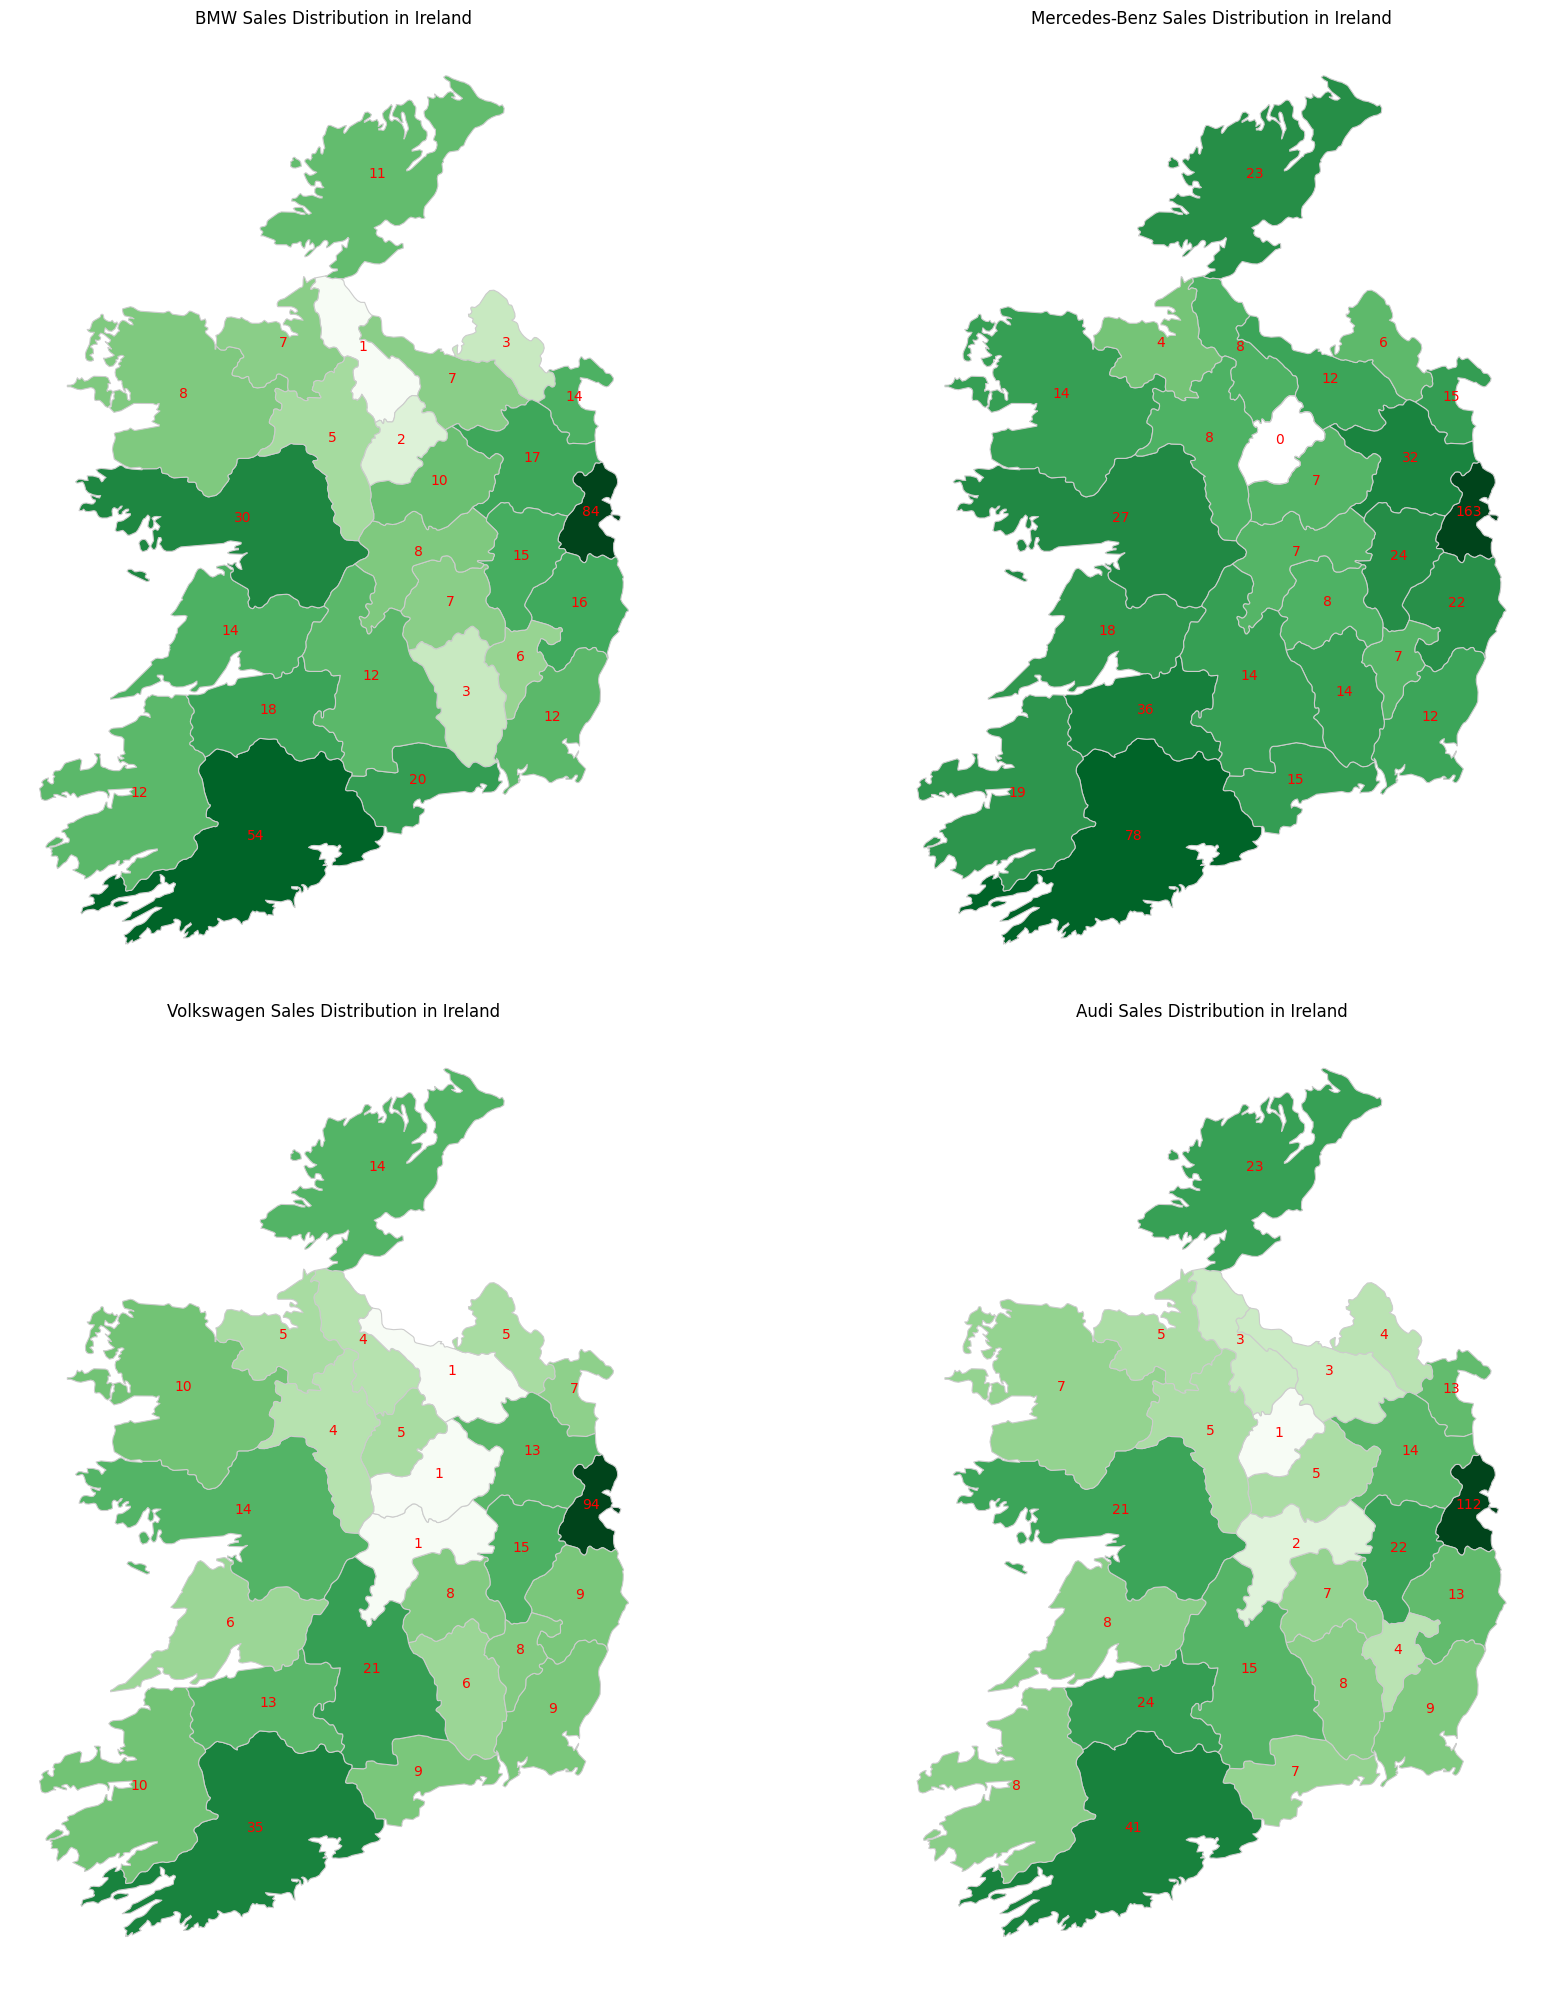

In [5145]:
# car brands to analyze.
brands = ["BMW", "Mercedes-Benz", "Volkswagen", "Audi"]

# Load the Irish counties GeoJSON from "ie.json"
gdf = gpd.read_file("ie.json")
county_name_col = None
for col in gdf.columns:
    if 'name' in col.lower():
        county_name_col = col
        break

# Replace "Laoighis" with "Laois".
gdf['name'] = gdf['name'].replace({"Laoighis": "Laois"})

# grid of subplots.
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
axes = axes.flatten()

for i, brand in enumerate(brands):
    df_brand = df[df['Make'] == brand]
    
    # Compute frequency counts for Sale Location for this brand.
    sale_location_counts_brand = df_brand['Sale Location'].value_counts().rename_axis('name').to_frame('Sales')
    sale_location_counts_brand.index = sale_location_counts_brand.index.astype(str).str.strip()
    # Merge sales data with the GeoDataFrame.
    gdf_brand=gdf.set_index("name").join(sale_location_counts_brand, how="left").reset_index()
    gdf_brand['Sales'] = gdf_brand['Sales'].fillna(0)
    # For logarithmic normalization
    gdf_brand['Sales_for_norm'] = gdf_brand['Sales'].replace(0, 0.1)
    norm = LogNorm(vmin=gdf_brand['Sales_for_norm'].min(), vmax=gdf_brand['Sales_for_norm'].max())
    # Plot map.
    ax = axes[i]
    gdf_brand.plot(column='Sales',cmap='Greens', norm=norm,linewidth=0.8,ax=ax,edgecolor='0.8')
    
    # Annotate each county with its sales number.
    for idx, row in gdf_brand.iterrows():
        ax.text(row.geometry.centroid.x, row.geometry.centroid.y, int(row['Sales']),horizontalalignment='center',color='Red')
    
    ax.set_title(f"{brand} Sales Distribution in Ireland")
    ax.set_axis_off()

plt.tight_layout()
plt.show()


From the location distribution of sales across Ireland for each brand of car the follwoing is deduced:
- Dublin is the clear leader: All brands have their highest sales in Dublin. Mercedes-Benz leads with 163 sales, followed by Audi (112), Volkswagen (94), and BMW (84).
- Regional differences emerge: In Cork Mercedes-Benz also shows a high count (78), while the other brands have lower counts (BMW: 54, Audi: 41, Volkswagen: 35). Similar patterns appear in other counties where Mercedes-Benz tends to have higher figures across multiple regions.
- Market segmentation by brand: Volkswagen consistently records lower sales across most counties compared to the other brands, Audi and BMW fall in between, while Mercedes-Benz dominates in most counties.
- Smaller counties: Rural counties (e.g., Longford, Leitrim, Offaly, Cavan) have very low sales for all brands, indicating that major urban areas drive most sales.

Overall, these results highlight strong concentration of sales in Dublin and reveal that Mercedes-Benz outperforms the other brands in many regions.

## 3.4 Car Usage Features Distribution

Key car usage features such as Mileage, Car Age, and their normalized values are visualized using histograms. Each histogram displays the frequency distribution of one feature, helping to identify patterns such as skewness, outliers, and the spread of values, important for understanding vehicle usage and depreciation trends.

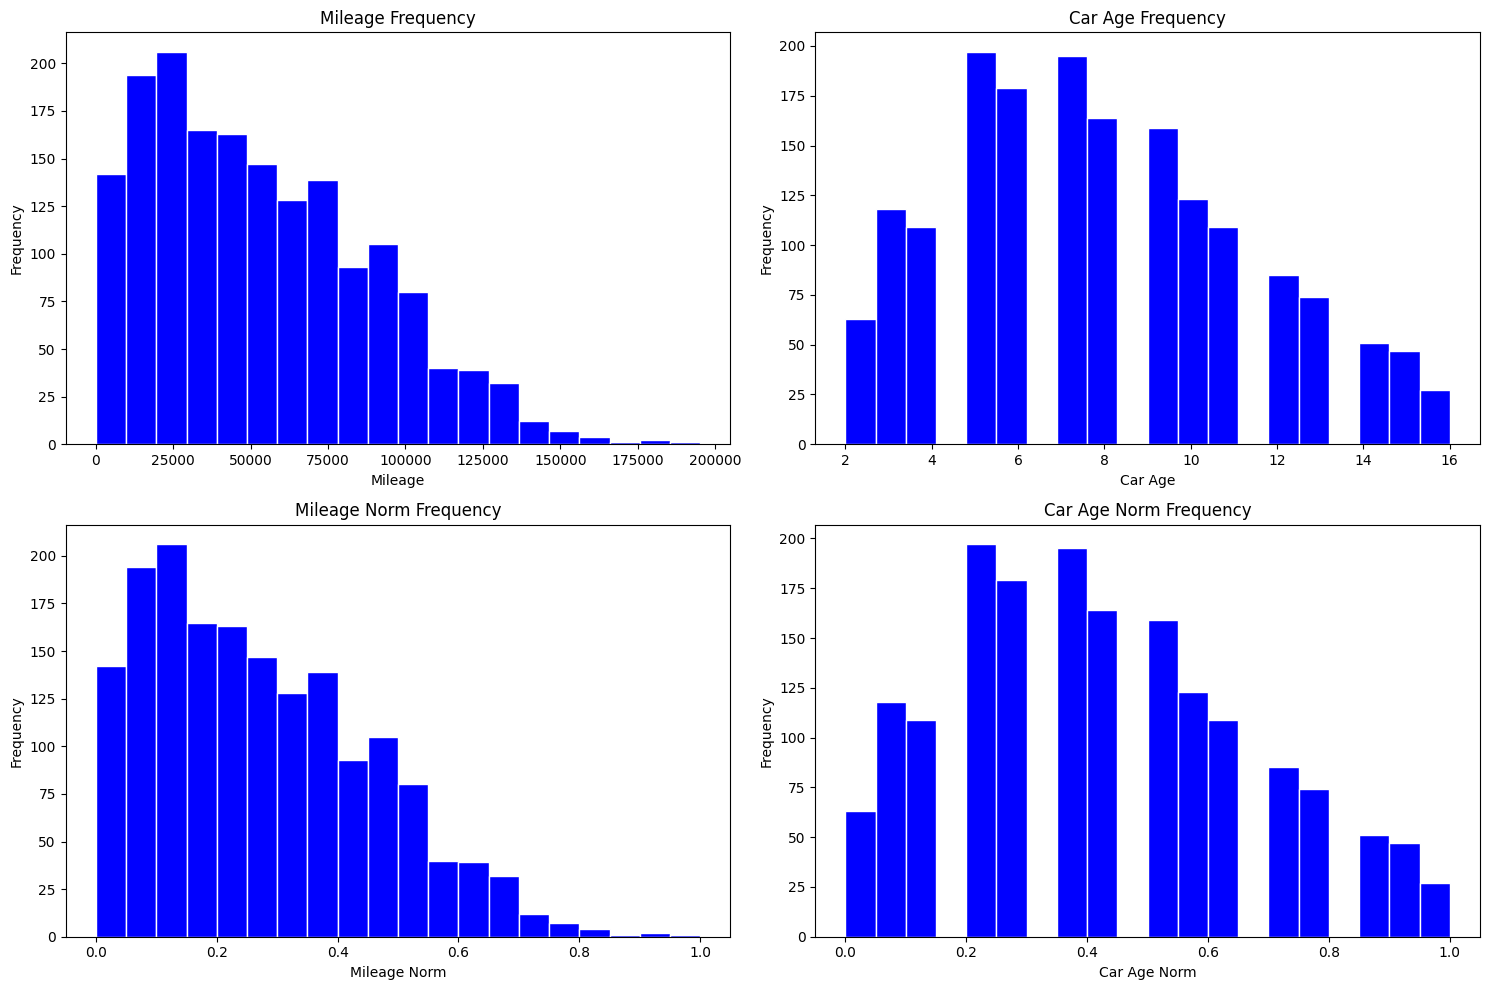

In [5146]:
# Car usage data to visualize
car_usage_features = [ 'Mileage', 'Car Age', 'Mileage Norm', 'Car Age Norm']
plt.figure(figsize=(15, 10))

# Plot a histogram for each feature
for i, feature in enumerate(car_usage_features, 1):
    plt.subplot(2, 2, i)
    plt.hist(df[feature].dropna(), bins=20, color='blue', edgecolor='white')
    plt.title(feature + ' Frequency')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


**Mileage:**
- The mileage histogram shows a right-skewed distribution, most vehicles cluster in the lower and mid mileage range with less with high mileages.

**Car Age:**
- The car age histogram peaks around 6 to 8 years suggesting a common replacement cycle and tapers off at higher ages fewer very old vehicles are sold.

## 3.5 Vehicle Metrics by Classification

Now to explore how metrics including Car Age, milage and sale price vary across the different types of car classifications. Boxplot are used to show the median values, interquartile ranges and potential outliers for each of these metrics. 

Car Age: Shows the distribution  of vehicle ages, helping to reveal how long vehicles in each classification are typically in use.

Mileage: Displays how accumulated mileage differs among classifications, which can show the usage intensity

Sale Price: Displays the spread in pricing across vehicle classes which provides insights into market valuation and depreciation trends.

A Scatterplot is also displayed showing the relationship between a vehicles age and its mileage for each classification, this identifies trends or clusters associated with different car classifications. i.e. whether older vehicles tend to have higher mileage across different classes

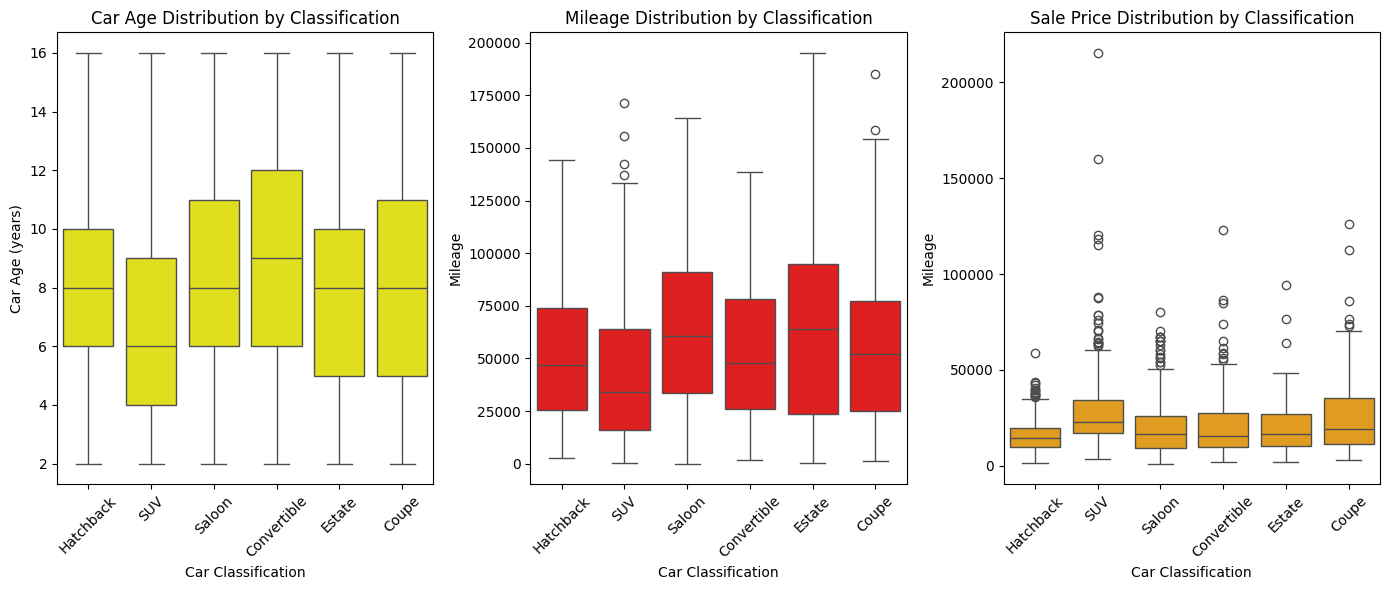

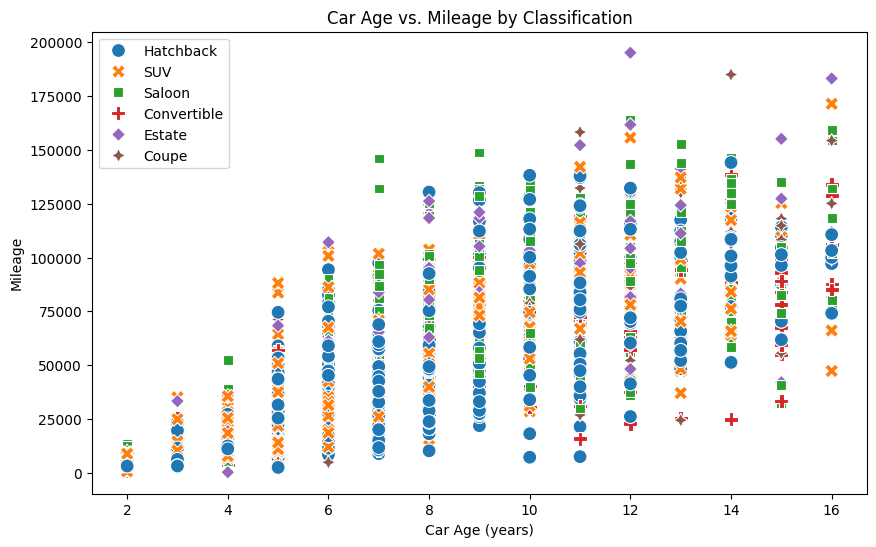

In [5147]:
# Visualize Car Age and Mileage and sale price distributions by Classification using boxplots.
plt.figure(figsize=(14,6))
plt.subplot(1,3,1)
sns.boxplot(data=df, x='Classification', y='Car Age', color='yellow')
plt.title('Car Age Distribution by Classification')
plt.xlabel('Car Classification')
plt.ylabel('Car Age (years)')
plt.xticks(rotation=45)

plt.subplot(1,3,2)
sns.boxplot(data=df, x='Classification', y='Mileage', color='red')
plt.title('Mileage Distribution by Classification')
plt.xlabel('Car Classification')
plt.ylabel('Mileage')
plt.xticks(rotation=45)

plt.subplot(1,3,3)
sns.boxplot(data=df, x='Classification', y='Sale Price', color='orange')
plt.title('Sale Price Distribution by Classification')
plt.xlabel('Car Classification')
plt.ylabel('Mileage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Create a scatter plot of Car Age vs. Mileage colored by Classification.
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Car Age', y='Mileage', hue='Classification', style='Classification', s=100)
plt.title('Car Age vs. Mileage by Classification')
plt.xlabel('Car Age (years)')
plt.ylabel('Mileage')
plt.legend()
plt.show()


**Car Age:**
- Convertibles median age is 9 years, indicating they tend to be a bit older compared to other types.
- Coupes, Estates, Hatchbacks, and Saloons groups show a similar median age of around 8 years, suggesting a consistent replacement cycle.
- SUV exhibits a lower median age of 6 years, implying newer vehicles overall.

**Mileage:**
- Estates and Saloons show higher typical mileage medians around 60,000, potentially showing they are used more extensively.
- Coupes have a slightly lower median around 50,000,  but have several outliers suggesting that most are driven moderately but some are driven heavily
- Convertibles and Hatchbacks have lower medians around 45,000 showing lighter usage.
- SUVs, with a median near 35,000, appear to be driven less on average but still include some outliers

**Sale Price:**
- Convertibles: Median sale price is approximately 16,000, with a wide range up to about 120,000, indicating a mix of budget and premium models.
- Coupes: Median sale price is around 20,000, with some high outliers, suggesting the presence of premium variants.
- Estates and Saloons: Both have medians in the mid-teens around 16,000, reflecting moderate pricing.
- Hatchbacks: Tend to be the most affordable, with a median around 14,000.
- SUV: Show the highest median sale price of around 23,000 along with several high-priced outliers, indicating a premium segment.

The scatter plot indicates that older cars generally rack up more mileage, with SUVs and Saloons often reaching higher extremes, while Coupes and Convertibles show lighter use showing varied driving patterns across classifications.

## 3.6 Monthly Trends in Average Sale Price and Sales Volume

Monthly aggregations are informative in the analysis of the data. Two sets of trends are computed and plotted using bar charts.

Average Sale Price by Month: Indicates the typical sale price for vehicles in each month.
Number of Cars Sold by Month: Reveals the sales volume, which might suggest seasonal demand.

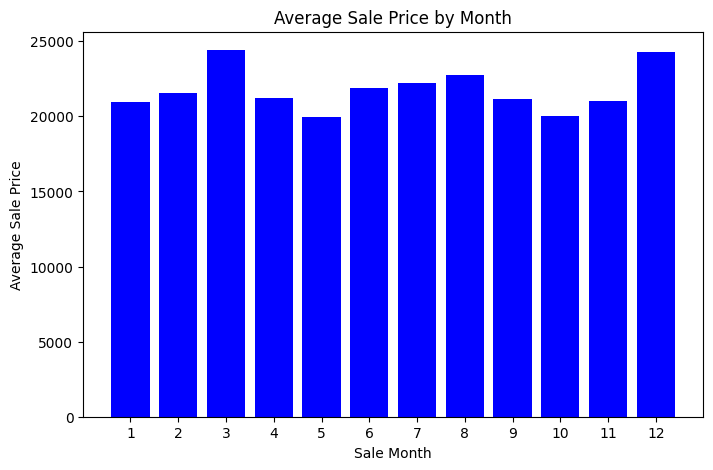

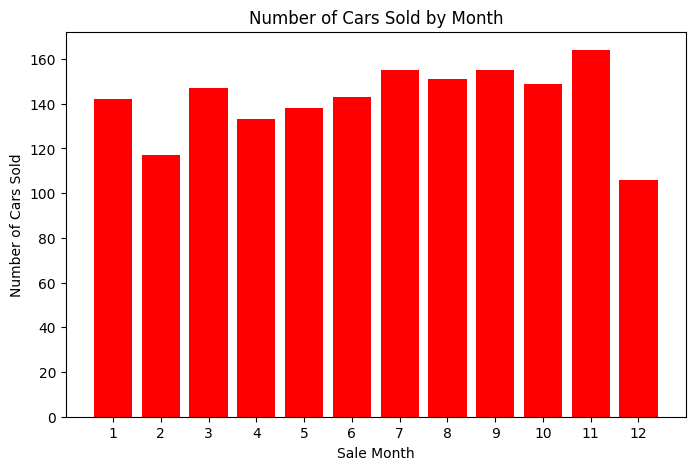

In [5148]:
# Extract Sale Month and Sale Year from the Date of Sale
df['Sale Month'] = df['Date of Sale'].dt.month
df['Sale Year'] = df['Date of Sale'].dt.year

# average sale price by month
avg_price_by_month = df.groupby('Sale Month')['Sale Price'].mean()

# number of cars sold per month
cars_sold_by_month = df.groupby('Sale Month').size()

# Plot average sale price by month
plt.figure(figsize=(8, 5))
plt.bar(avg_price_by_month.index, avg_price_by_month.values, color='blue')
plt.xlabel('Sale Month')
plt.ylabel('Average Sale Price')
plt.title('Average Sale Price by Month')
plt.xticks(range(1, 13))
plt.show()

# Plot number of cars sold by month
plt.figure(figsize=(8, 5))
plt.bar(cars_sold_by_month.index, cars_sold_by_month.values, color='red')
plt.xlabel('Sale Month')
plt.ylabel('Number of Cars Sold')
plt.title('Number of Cars Sold by Month')
plt.xticks(range(1, 13))
plt.show()

**Average Sale Price by Month:**
- This chart shows that average sale prices vary from month to month, with some months showing higher prices (months 3 & 7) than others. Factors such as seasonal demand, events, or shifts in consumer spending habits could be the potential drivers these monthly changes.

**No. of Car Sold by Month:**
- This chart shows that total car sales also fluctuate throughout the year. Certain months (2, 9, 10, and 11) have stronger sales volumes, suggesting possible seasonal peaks in buyer activity. A note-worthy observation is the drop in sales from November to December, a potential reason for this is buyers are willing to wait until the new year to get the newer registration which would potentially increase the value of their car.

## 3.7 Brand-Specific Monthly Trends

Examine trends for each car brand with both average sale price and the number of cars sold per month.

Data is grouped by both car brand and sale month. The data is visualized using plots.

Brand Price Trends: Comparing average sale prices for different brands across months.
Brand Sales Volume Trends: Observing how many vehicles from each brand were sold each month.

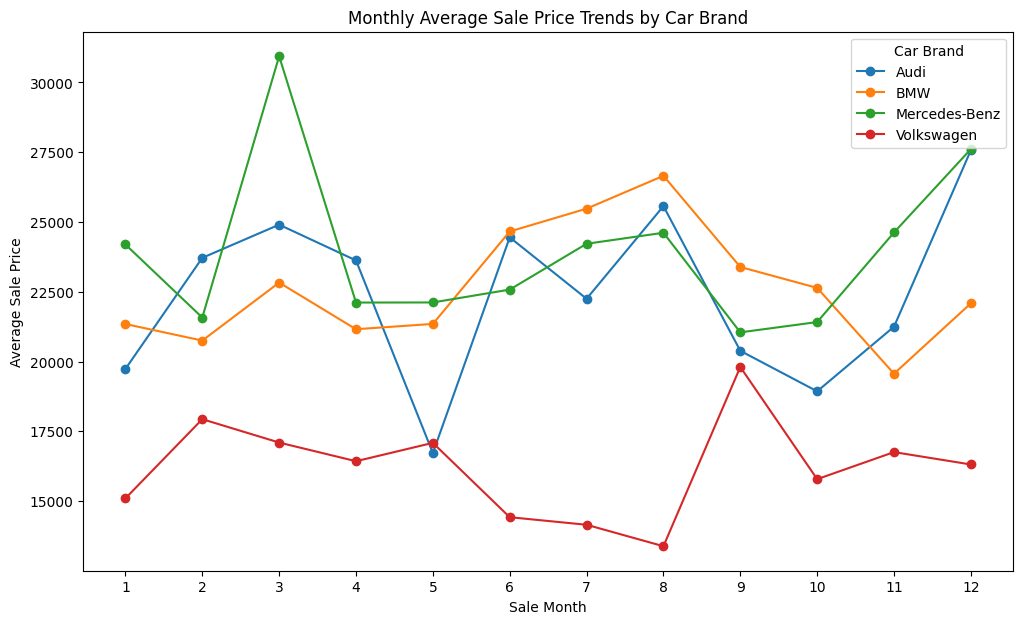

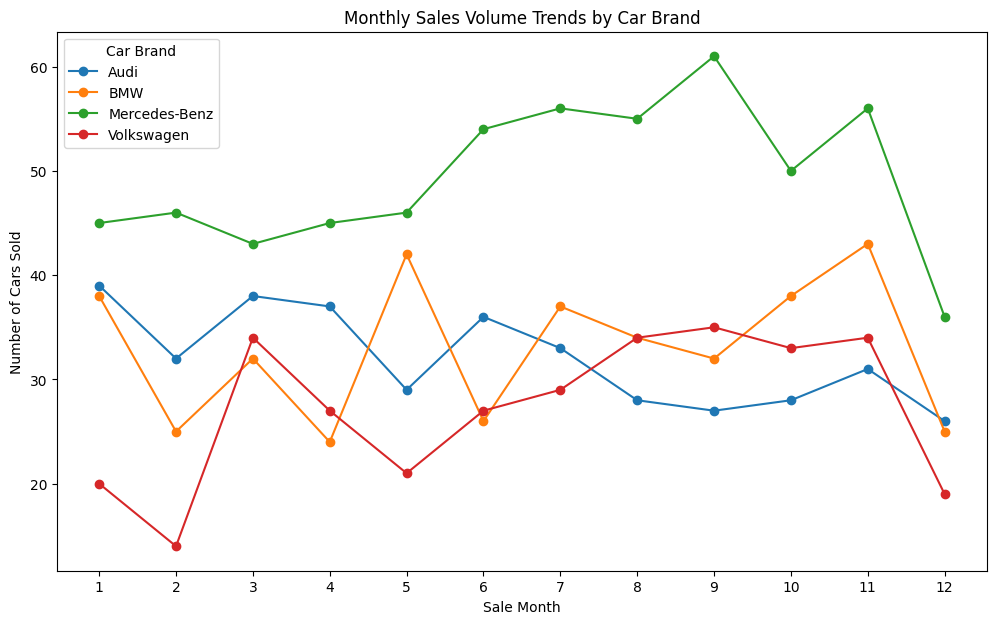

In [5149]:
# Group and compute mean Sale Price and count for each brand per month.
brand_monthly_price = df.groupby(['Make', 'Sale Month'])['Sale Price'].mean().reset_index()
brand_monthly_count = df.groupby(['Make', 'Sale Month']).size().reset_index(name='Sales Count')

# Pivot to have Sale Month as rows and brands as columns for average sale price.
brand_price_df = brand_monthly_price.pivot(index='Sale Month', columns='Make', values='Sale Price')

# Pivot to have Sale Month as rows and brands as columns for sales count.
brand_sales_df = brand_monthly_count.pivot(index='Sale Month', columns='Make', values='Sales Count')

# Plot the monthly average sale price trends for each car brand.
plt.figure(figsize=(12, 7))
for brand in brand_price_df.columns:
    plt.plot(brand_price_df.index, brand_price_df[brand], marker='o', label=brand)
plt.xlabel('Sale Month')
plt.ylabel('Average Sale Price')
plt.title('Monthly Average Sale Price Trends by Car Brand')
plt.xticks(range(1, 13))
plt.legend(title='Car Brand')
plt.show()

# Plot the monthly sales count trends for each car brand.
plt.figure(figsize=(12, 7))
for brand in brand_sales_df.columns:
    plt.plot(brand_sales_df.index, brand_sales_df[brand], marker='o', label=brand)
plt.xlabel('Sale Month')
plt.ylabel('Number of Cars Sold')
plt.title('Monthly Sales Volume Trends by Car Brand')
plt.xticks(range(1, 13))
plt.legend(title='Car Brand')
plt.show()


**Monthly Average Sale Price by Brand:**
- Each brand’s line shows month-to-month price fluctuations. Premium brands like Mercedes-Benz generally have higher prices, while mainstream brands like Volkswagen show lower averages. Seasonal peaks or dips may reflect new model release or changes in demand. 

**Monthly Sales Volume by Brand:**
- The lines for sales volume indicate which brands sell more cars in certain months, some brands see strong volume spikes that coincide with stable or rising prices, suggesting high demand.Fluctuations could potentially be attested to external factors such as economic conditions or competitor actions. It is again worth noting the drop in sales from November to December is a consistent trend across all the car brands as previously identified with overall car sales.

## 3.8 Car Model Pricing and Frequency Analysis

To examine the relationship between car models and their sale prices, as well as how frequently each model appears in the dataset
Identify the top 10 models by average sale price (to highlight premium, high value vehicles).
Identify the bottom 10 models by average sale price (to show budget friendly options).
Determine the top 10 most common models (to understand market dominance).

Model
G Class      4
X6 M         1
Rsq8         1
Amg Gt       5
SQ8          2
IX           1
GLS Class    1
R8           4
RS6 Avant    2
Eqc          2
Name: count, dtype: int64
Model
SLK             10
Polo            55
CC               8
up!              4
Beetle           1
CLK              3
Golf Plus        2
CLC Class        4
Eos              1
A4 Cabriolet     2
Name: count, dtype: int64
Model
C Class      147
A Class      123
E Class      115
Golf         101
1 Series      81
Polo          55
Tiguan        54
3 Series      53
GLA Class     45
5 Series      42
Name: count, dtype: int64


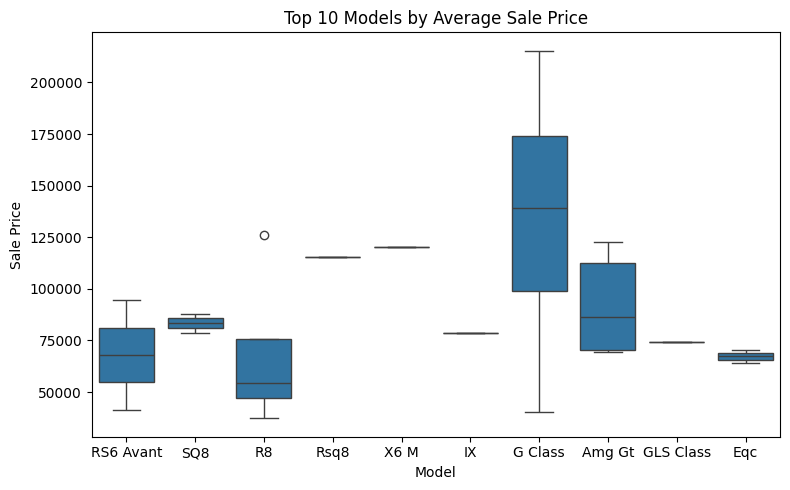

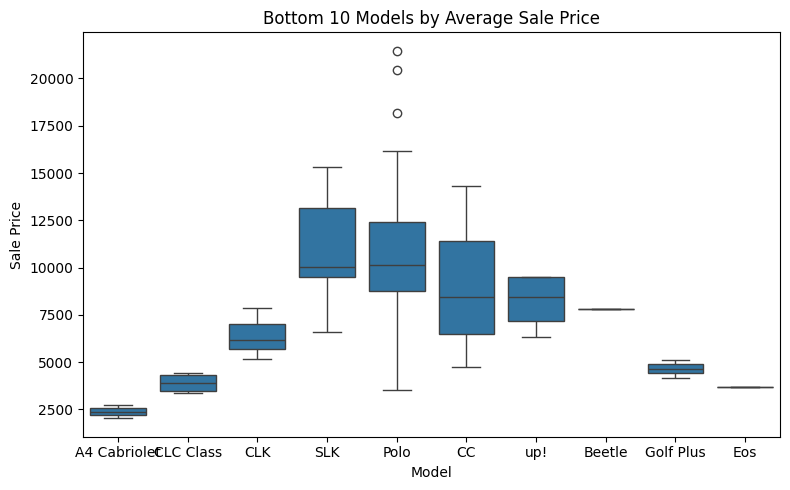

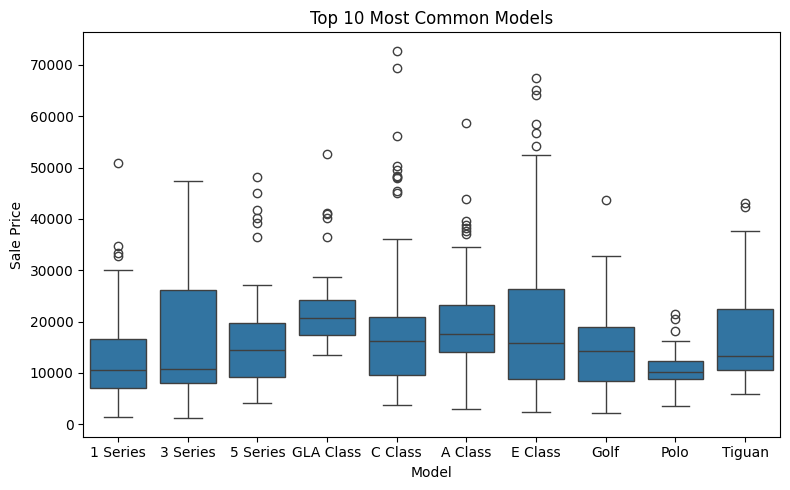

In [5150]:
# calculate average sale price per model in decending order.
model_avg = df.groupby('Model')['Sale Price'].mean().sort_values(ascending=False)

# get the top 10 and bottom 10 models by average sale price.
top10_models = model_avg.head(10).index.tolist()
bottom10_models = model_avg.tail(10).index.tolist()

# get 10 most common models.
model_counts = df['Model'].value_counts()
common_models = model_counts.head(10).index.tolist()

# get counts
top10_counts = model_counts.loc[top10_models]
bottom10_counts = model_counts.loc[bottom10_models]
common_counts = model_counts.loc[common_models]

# Print the calculated sections of the models types
print(top10_counts)
print(bottom10_counts)
print(common_counts)

# Boxplot for Top 10 Models by Average Sale Price.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[df['Model'].isin(top10_models)], x='Model', y='Sale Price')
plt.title("Top 10 Models by Average Sale Price")
plt.tight_layout()
plt.show()

# Boxplot for Bottom 10 Models by Average Sale Price.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[df['Model'].isin(bottom10_models)], x='Model', y='Sale Price')
plt.title("Bottom 10 Models by Average Sale Price")
plt.tight_layout()
plt.show()

# Boxplot for Top 10 Most Common Models.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[df['Model'].isin(common_models)], x='Model', y='Sale Price')
plt.title("Top 10 Most Common Models")
plt.tight_layout()
plt.show()

**Interpretation of Model Pricing and Frequency Analysis**

- **Top 10 Models by Average Sale Price:**  
  - These models like G Class, X6 M, Rsq8, Amg Gt are luxury or performance vehicles with very high average sale prices (ranging from 65k to 135,000k).
  - Their low counts mostly 1 to 5 units suggest they are rare and are representing a premium market segment.

- **Bottom 10 Models by Average Sale Price:**  
  - Models like SLK, Polo, CC, and up! fall in the lower price range (averages between 2000 and 11,000).  
  - These vehicles are likely positioned as budget-friendly options, and some are sold in higher volumes.

- **Top 10 Most Common Models:**  
  - Mainstream models like the C Class, A Class, E Class, Golf, 1 Series dominate in terms of frequency.  
  - Their average sale prices (13,000 to 22,000) are moderate, reflecting a balance between affordability and brand.
  
The analysis reveals that the luxury high priced models are less frequent, while mainstream models are more common.


## Part 4: Correlation Analysis

## 4.1 Relationship Between Sale Price and Vehicle Condition

To evaluate how usage and condition metrics such as mileage and car age and No. of previous owners effect sale price.
Scatter plots of Sale Price vs Mileage and Sale Price vs Car Age and Sale Price vs Previous Owners are used.
Correlation coefficients are computed for a quantitative measure.

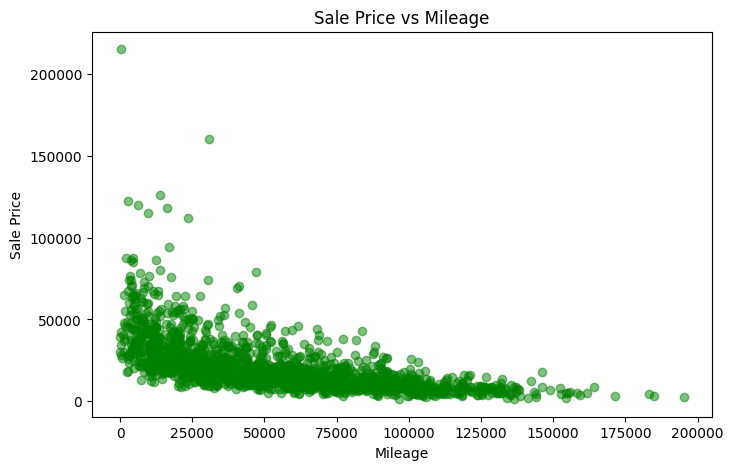

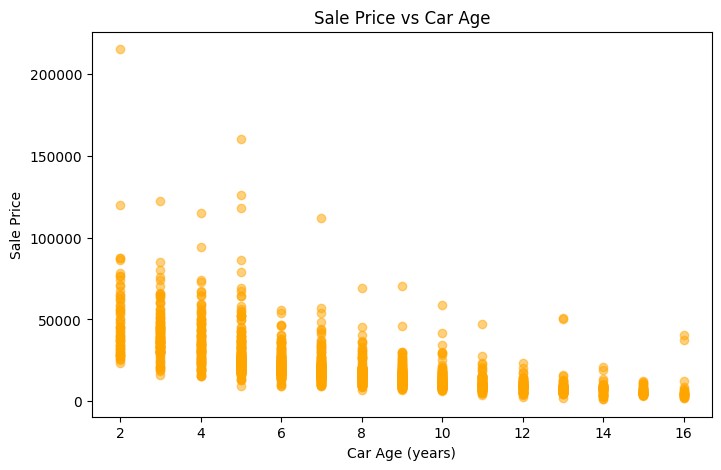

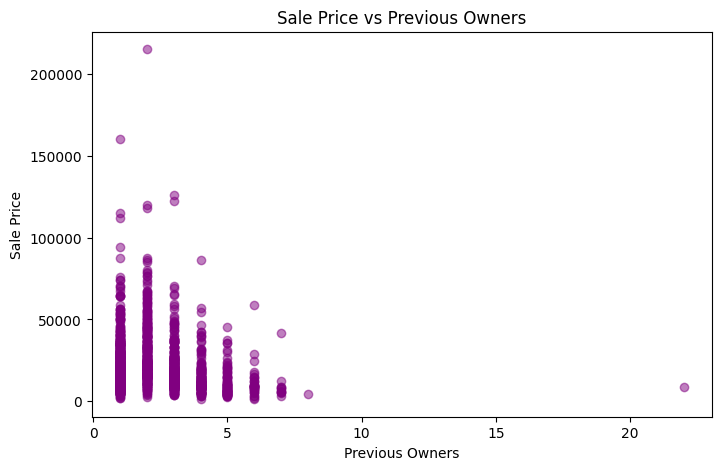

Correlation between Sale Price and Mileage: -0.590817
Correlation between Sale Price and Car Age: -0.650050
Correlation between Sale Price and Previous Owners: -0.197219


In [5151]:
# Sale Price vs Mileage scatter
plt.figure(figsize=(8, 5))
plt.scatter(df['Mileage'], df['Sale Price'], alpha=0.5, color='green')
plt.xlabel('Mileage')
plt.ylabel('Sale Price')
plt.title('Sale Price vs Mileage')
plt.show()

# Sale Price vs Car Age Scatter
plt.figure(figsize=(8, 5))
plt.scatter(df['Car Age'], df['Sale Price'], alpha=0.5,color='orange')
plt.xlabel('Car Age (years)')
plt.ylabel('Sale Price')
plt.title('Sale Price vs Car Age')
plt.show()

# Sale Price vs Previous Owners scatter
plt.figure(figsize=(8,5))
plt.scatter(df['Previous Owners'], df['Sale Price'], alpha=0.5,color='purple')
plt.xlabel('Previous Owners')
plt.ylabel('Sale Price')
plt.title('Sale Price vs Previous Owners')
plt.show()

# correlation coefficients
c_mileage = df['Sale Price'].corr(df['Mileage'])
c_age = df['Sale Price'].corr(df['Car Age'])
c_prev = df['Sale Price'].corr(df['Previous Owners'])
print(f"Correlation between Sale Price and Mileage: {c_mileage:f}")
print(f"Correlation between Sale Price and Car Age: {c_age:f}")
print(f"Correlation between Sale Price and Previous Owners: {c_prev:f}")


On analysis of the plots and correlation calculations the following is interpreted from the results:

**Sale Price vs. Car Age (Correlation: -0.65):**
The plot along with the moderate negative correlation reveals the strongest negative relationship among the three. As a car get older its sale price drop more. The clustering of lower prices at higher ages reflects typical market depreciation.

**Sale Price vs. Mileage (Correlation: -0.59):**
The scatter plot shows that higher mileage generally corresponds to lower sale prices, forming a downward trend. This moderate negative correlation indicates that accumulated mileage is a key factor in depreciation although not as much as vehicle age.

**Sale Price vs. Previous Owners (Correlation: -0.20):**
The scatter plot suggests that more owners do lower a car’s value, but not as much as age or mileage. While there is a negative trend, the weak negative correlation indicates that a buyer does consider past ownership but it is less relevant than usage or overall age.

## 4.2 Correlation Matrix & Heatmap

Compute the correlation coefficients for all numeric columns (sale price, mileage, car age, previous owners, engine size) and visualize them as a heatmap

This gives an overall view of how each numeric variable relates to the others

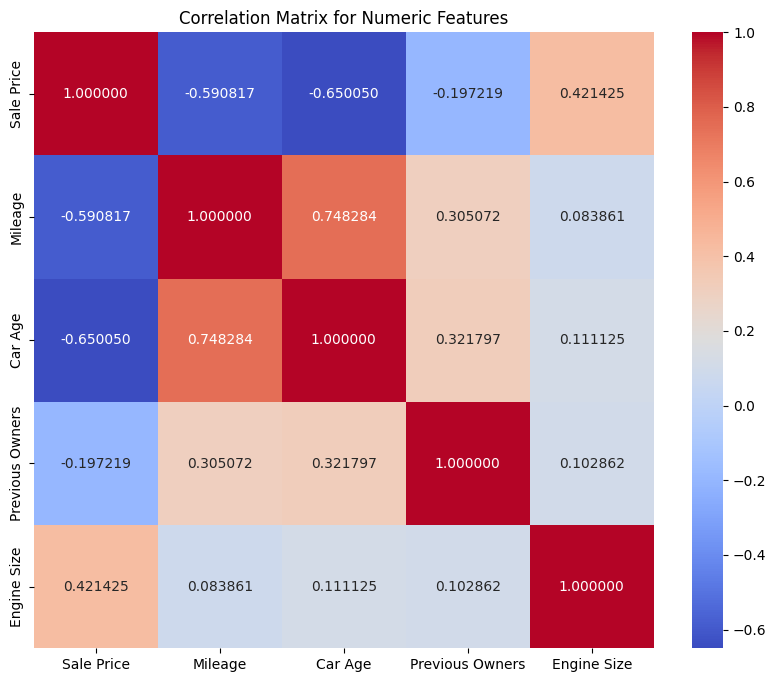

In [5152]:
# Making a correlation matrix and heat map
numeric_features = ['Sale Price', 'Mileage', 'Car Age', 'Previous Owners', 'Engine Size']
corr_matrix = df[numeric_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt="f")
plt.title('Correlation Matrix for Numeric Features')
plt.show()


**Correlation Matrix Interpretation:**

Correlations between mileage, age and previous owners was previously disscussed.

**Sale Price vs. Engine Size (0.42):**  
- A moderate positive correlation indicating that larger engines typically mean higher prices, likely due to performance.

**Mileage vs. Car Age (0.75):**  
- These two usage metrics are closely linked hence the strong positive correlation older cars naturally accumulate more miles over time.

**Mileage vs. Previous Owners (0.31)**  
   - A weak positive correlation means vehicles with higher mileage are slightly more likely to have changed hands multiple times.

**Mileage vs. Engine Size (0.08)**  
 - A very weak positive correlation: engine size does not heavily influence how many miles a vehicle accumulates.

**Car Age vs. Previous Owners (0.32)**  
 - A weak positive correlation: older cars tend to have more owners, although it’s not a dominant factor.

**Car Age vs. Engine Size (0.11)**  
 - A very weak positive relationship: engine size has little to do with how old a car is in this dataset.

**Previous Owners vs. Engine Size (0.10)**  
- A very weak positive correlation: there’s no strong tendency for larger-engine cars to have more (or fewer) owners.

**Correlation Analysis Takeaways**  
- **Age and Mileage** are the primary drivers of depreciation and strongly reduce sale price.  
- **Engine Size** slightly increases sale price, reflecting a performance factor.  
- **Number of Previous Owners** effects value but is less critical than age or mileage.  
- **Usage Metrics** (age, mileage) closely track each other and cars with alot of mileage/age often pass through multiple owners.

## Step 4: Modelling and Prediction

## 4.1 Simple Linear Regression (Sale Price Prediction Using Milage as a predictor)
 **Predictor:** Mileage 
 
This model will evaluate the basic relationship between mileage and sale price. Higher mileage is expected to lower the sale price.

Intercept: 36225.957063689915
Coefficient for Mileage: -0.2718246802294833


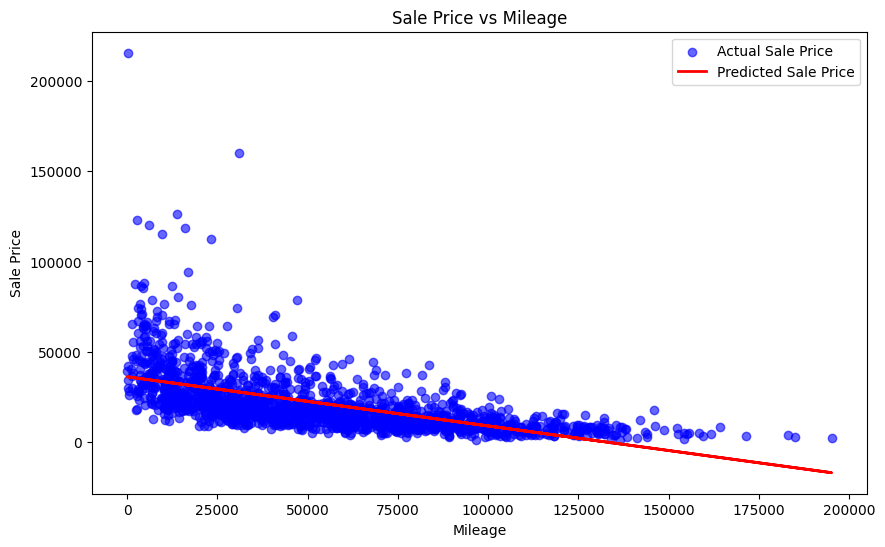

R Squared Value: 0.34906510477270103
Root Mean Squared Error: 13272.84414331318
Mean Absolute Error: 8551.229325187125


In [5153]:
# Use the full dataset without removing outliers
X = df[['Mileage']]

# Fit a simple linear regression model
Simple_model = LinearRegression()
Simple_model.fit(X, df['Sale Price'])

# Predict sale prices
y_pred = Simple_model.predict(X)

# Model Performace
rmse = root_mean_squared_error(df['Sale Price'], y_pred)
r2 = r2_score(df['Sale Price'], y_pred)
mae = mean_absolute_error(df['Sale Price'], y_pred)

# Model parameters
print("Intercept:", Simple_model.intercept_)
print("Coefficient for Mileage:", Simple_model.coef_[0])

# Plot actual sale prices and the regression line
plt.figure(figsize=(10,6))
plt.scatter(X, df['Sale Price'], color='blue', alpha=0.6, label='Actual Sale Price')
plt.plot(X, y_pred, color='red', linewidth=2, label='Predicted Sale Price')
plt.xlabel("Mileage")
plt.ylabel("Sale Price")
plt.title("Sale Price vs Mileage")
plt.legend()
plt.show()

print(f"R Squared Value: {r2}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")

# Results for Model 4.1:

- **R²:** 0.349 – About 35% of the variation in sale price is explained by mileage alone.
- **RMSE:** On average, the predicted sale price is off by about 13,273.
- **MAE:** The mean absolute error of 8,551.23 indicates a pretty big average prediction error.

Using mileage alone on the full dataset results in an okay model fit. Outliers probably inflate the error metrics.


Significant outliers are identified hence these cases are dropped and recalculate the regression model on the rest of
the data. This is done because regression models assume no significant outliers as they can lead to a bad regression fit.

## 4.2 Simple Linear Regression (Sale Price with Outliers Removed prediction Using Milage as a predictor)

Intercept: 30366.19942749758
Coefficient for Mileage: -0.20327466485010084


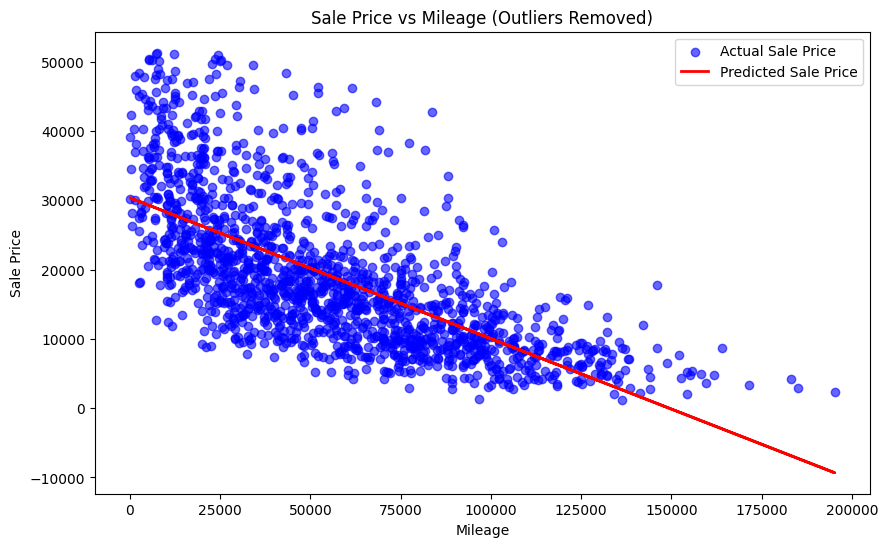

R Squared Value: 0.4494319211543387
Root Mean Squared Error: 7958.714750458627
Mean Absolute Error: 6120.50211230996


In [5154]:
# Remove outliers from Sale Price using the IQR method
Q1 = df['Sale Price'].quantile(0.25)
Q3 = df['Sale Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_clean = df[(df['Sale Price'] >= lower_bound) & (df['Sale Price'] <= upper_bound)]

# predictor and target using the cleaned dataset
X_clean = df_clean[['Mileage']]
y_clean = df_clean['Sale Price']

# Fit a simple linear regression model on clean data
Simple_model_1 = LinearRegression()
Simple_model_1.fit(X_clean, y_clean)

# Predict sale prices with the model
y_pred = Simple_model_1.predict(X_clean)

# Model Performace
rmse = root_mean_squared_error(y_clean, y_pred)
r2 = r2_score(y_clean, y_pred)
mae = mean_absolute_error(y_clean, y_pred)


# Output model parameters
print("Intercept:", Simple_model_1.intercept_)
print("Coefficient for Mileage:", Simple_model_1.coef_[0])

plt.figure(figsize=(10, 6))
plt.scatter(X_clean, y_clean, color='blue', alpha=0.6, label='Actual Sale Price')
plt.plot(X_clean, y_pred, color='red', linewidth=2, label='Predicted Sale Price')
plt.xlabel("Mileage")
plt.ylabel("Sale Price")
plt.title("Sale Price vs Mileage (Outliers Removed)")
plt.legend()
plt.show()

print(f"R Squared Value: {r2}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")

# Results for Model 4.2: Mileage Only (Outliers Removed)
- **R²:** 0.449 – The model with outliers removed  now explains about 45% of the variation in sale price.
- **RMSE:** Prediction error drop to 7,958.71 after removing outliers.
- **MAE:** Lower average error of 6,120.50 indicates a more reliable prediction.

Removing outliers improves the model’s performance, highlighting that mileage has a stronger relationship with sale price when outliers are removed.


## 4.3 Multiple Regression (Sales Price with Outliers Removed is predicted using Usage metrics as predictors)

**Predictors:** Mileage, Car Age, and Previous Owners

This model is expected to be more accurate by including additional indicators of vehicle condition. Older age and more previous owners typically lower a car’s value.

Intercept: 37686.32621656261
Coefficients: [-7.93905121e-02 -1.79979668e+03  1.44808093e+02]


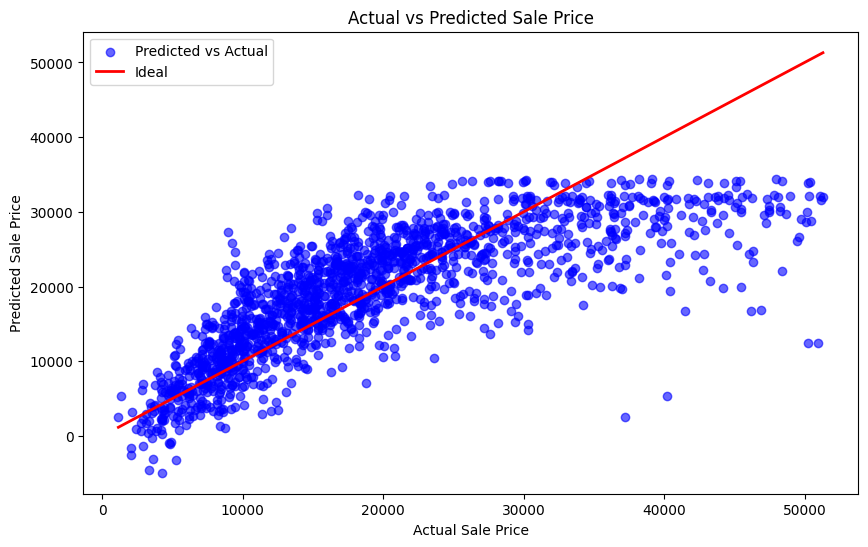

R Squared Value: 0.5989702756894186
Root Mean Squared Error: 6792.4383793756915
Mean Absolute Error: 4944.521159888727


In [5155]:
# Set up predictor and target for multiple regression
X = df_clean[['Mileage', 'Car Age', 'Previous Owners']]
y = df_clean['Sale Price']

# Fit the multiple linear regression model
multiple_model = LinearRegression()
multiple_model.fit(X, y)

# Output model parameters and performance
print("Intercept:", multiple_model.intercept_)
print("Coefficients:", multiple_model.coef_)

# Predict sale prices using the fitted model
y_pred = multiple_model.predict(X)

# Model Performace
rmse = root_mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

# scatter plot of actual vs predicted sale prices
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='r', linewidth=2, label='Ideal')
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Sale Price")
plt.legend()
plt.show()

print(f"R Squared Value: {r2}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")

# Results for Model 4.3: Mileage, Car Age, and Previous Owners
- **R²:** 0.599 – Around 60% of the sale price variation is explained with all the usage metrics as predictors.
- **RMSE:** Reduction in error to 6,792.44 shows a better model performance.
- **MAE:** Improved average prediction error with multiple regression to 4,944.52.

Adding car age and previous owners significantly enhances the model. These variables capture additional aspects of vehicle condition which makes the model stronger at predicting sale price.

## 4.4 Multiple Regression (Sales Price wiht Outliers Removed is predicted using Usage Metrics and Car Model as predictors)

**Predictors:** Mileage, Car Age, Previous Owners, and Car Model (model converted into dummy variables)

This model enhances onto the previous model by incorperating the car model as a predictor, it is expected to be the strongest model of the four linear regression models

Intercept: 35260.63141428567


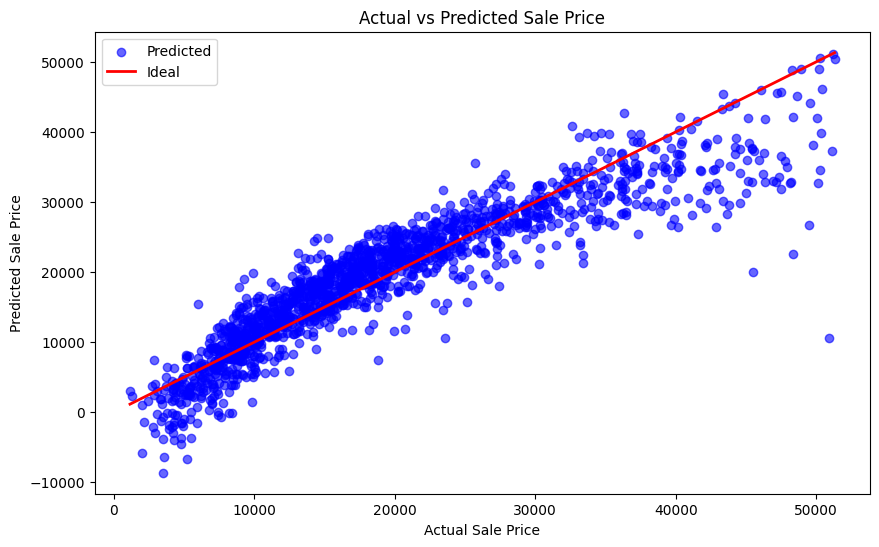

R Squared Value: 0.8385176571377606
Root Mean Squared Error: 4310.225046360981
Mean Absolute Error: 3093.94578459309


In [5156]:
# Create predictor by joining continuous variables and dummies for model.
X = df_clean[['Mileage', 'Car Age', 'Previous Owners']].join(pd.get_dummies(df['Model'], drop_first=True))
y = df_clean['Sale Price']

# Fit the multiple linear regression model.
multiple_model_1 = LinearRegression()
multiple_model_1.fit(X, y)

# Output model parameters.
print("Intercept:", multiple_model_1.intercept_)

# Predict sale prices using the model.
y_pred = multiple_model_1.predict(X)

# Model Performace
rmse = root_mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

# scatter plot to visualize actual vs predicted sale prices.
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.6, label='Predicted')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='r', linewidth=2, label='Ideal')
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Sale Price")
plt.legend()
plt.show()

print(f"R Squared Value: {r2}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")

# Results for Model 4.4: Mileage, Car Age, Previous Owners, and Car Model

- **R²:** 0.839 - The model now explains about 84% of the variation in sale price.
- **RMSE:** 4,310.23 error, indicates a high prediction accuracy.
- **MAE:** A very low average error of 3093.95, reflects a strong prediction.

Incorporating car model information dramatically improves the model. This suggests that the specific car model is a key indicator of sale price, alongside mileage, age, and previous ownership. Thsi give a highly accurate prediction model

## Part 5: Disscussion

## Data Scraping and Cleaning Challenges

 - **Handling CSV Encoding Issues**
  One challenge encountered during data scraping was ensuring that special characters (€ sign) are preserved when saving the scraped data to a CSV file. When there isnt proper encoding these characters can become corrupted or misinterpreted.To overcome this the CSV file was saved using the UTF-8-sig encoding. This encoding ensures that special characters are handled correctly.
 
- **Navigating Car Types and Pages:**  
  One challenge was navigating through all car types listed on the main page, then iterating through each of their paginated subpages to ensure complete scraping of data. This required building the logic to first extract all car type URLs, then to detect and loop through the pages for each type to ensure all sales data is recorded and preventing missed records or duplicate entries across pages for each car brand.

- **Inconsistent Data Formats:**  
  The raw data contained various formats for dates and numbers which required inspection in order to clean and standardize properally. For example, dates appeared in multiple formats. This necessitated careful handling to ensure consistency in the date formatting. To overcome this a function was created to 

- **Categorical Discrepancies:**  
  There were inconsistencies in categorical columns which to be observed by inspecting the unique values in each column to identify these inconsistencies (SUV and S.U.V. or Auto and Automatic) that complicated data merging and analysis. These issues had to be resolved through manual correction and replacement, which was both time-consuming and error-prone.

- **Extracting Information from Descriptions:**  
  Another challenge was extracting data from the free-text Description column. Important details such as engine size, car colour, and number of previous owners were embedded in unstructured sentences and not always in the same format. To handle this, custom regular expressions and string matching logic was used to identify and extract this data like numeric engine sizes in the form "2.0" or "3.0L" and ownership history "2 previous owners"). This required careful parsing to avoid false matching or non detection especially formatted inconsistently or appeared in multiple places in a description.

## Key Insights from Data Analysis

- **Sales Location:**  
  Car sales are considerably higher in urban counties with Dublin and Cork dominating the distribution followed by Limerick and Galway. This suggests higher demand in more densely populated and economically active regions.

- **Most Popular Vehicle Types:**  
  Hatchbacks and SUVs were the most commonly sold car type showing there is a market preference for compact and versatile vehicles. Te most commonly sold cars approximately ranged in prices between 13,000 and 22,000 euro. The Premium brands Mercedes-Benz, BMW, and Audi were especially dominant with Volkswagen lagging behind in the number of sales.

- **Market Characteristics:**  
  The market is predominantly second hand sales but with some cars changing hands more times (3rd or 4th hand). Diesel and petrol engines were most common, with electric and hybrid vehicles still relatively rare this showing that the market is still prominently fossil fuel powered cars despite the move towards EVs.

- **Relationship Trends:**  
  Sale price showed the strongest correlation with mileage where there was a negative correlation of 0.59 this indicates that driving factor of the deprecation of price was the amount the car is used. Age also had a negative correlation to sale price but less prevalent than mileage and similarly with the number of previous owners. High average sale prices and low number of sales on premium cars was identified, this is as expected as they are tailored to a smaller segment of the customer base. The strongest relationship identified was between Age and Mileage which is as to be expected, another relationship identified was the correletion between sale price and the engine size which had a positive correlation of 0.42.

- **Monthly Sale Trends** 
  Monthly trends in average sale price and sales volume were analyzed to understand seasonal patterns in the market. It revealed that car sales peaked in November and dropped significantly in December, suggesting a potential end-of-year purchasing cycle (customers wait until the new year to purchase). When broken down by brand Volkswagen had lower sales volume in the majority months compared to the other major brands along with their average sale price also being lower across the months.

- **Model-Based Insights:**  
  Multiple regression models were developed to predict sale price using features such as mileage, car age, previous owners, and car model. The models showed that adding more relevant predictors significantly improved accuracy. Starting with just mileage gave a model with okay predictive power which improved alot when removing the outliers, but incorporating car age and ownership history improved the model's fit considerably. The most impactful boost which gave a model with an R squared score of 0.83 was when including car model as a dummy encoded categorical variable, which was able to incorporate brand and specification pricing differences. This highlights that car model which reflects car brand and style is a critical for predicting price.

These insights provide a clear image of the Irish used car market by highlighting customer preference and market dynamics, and the key factors that influence sale prices.

## Suggestions for Further Work

- **Integrate External Data Sources:**  
  Adding data on fuel price trends or real time demand data could improve the analysis of pricing and sales behavior.

- **Expanding Sales Data**
  Adding a variety of car brands to the data may give better insights into the second hand car market and allow for more accurate analysis

- **Improved Model Features:**  
  Additional variables such as car condition, service history, or dealership information could boost regression model's accuracy and give a better prediction of sale price.

- **Logistic Regression Models for Classification:**  
   Logistic regression could be expanded to classify cars into price categories ('Budget', 'Affordable', 'Mid range', etc.). This would allow for a more interpretable and simplified view of price segmentation rather than predicting continuous prices. Models like this could be valuable for quickly categorizing sales. Additional classification models such as Decision Trees and Gradient Boosts could also be used for comparison and improving the model's performance.

- **Classification of Buyers:**  
  If Customer-Related data was available, segmentation based on buyer type could help tailor marketing strategies. Applying unsupervised learning techniques like K-Means clustering could help uncover natural groupings of customers and vehicles based on attributes such as mileage, age, and price. This could help with tailoring marketing pricing strategies accordingly.

- **Improved Outlier Detection and Treatment:**  
  A more in depth approach to outlier detection and handling such as using isolation forests or statistical bootstrapping could be potentially applied to make sure the models are not skewed by extreme values.


These additions would deepen the analytical value of the dataset, improve prediction accuracy, and offer better insights.


## References

Making Cloropleth map:
https://www.datacamp.com/tutorial/geopandas-tutorial-geospatial-analysis

How to Use Regular expressions:
https://docs.python.org/3/library/re.html

GEOjson for Irish Counties:
http://simplemaps.com/gis/country/ie